In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/Datathon2026')

In [3]:
import pandas as pd
import numpy as np

df_customers = pd.read_csv('./dataset/customers.csv')
df_geography = pd.read_csv('./dataset/' + 'geography.csv')
df_inventory = pd.read_csv('./dataset/' + 'inventory.csv')
df_orders = pd.read_csv('./dataset/' + 'orders.csv')
df_order_items = pd.read_csv('./dataset/' + 'order_items.csv')
df_payment = pd.read_csv('./dataset/' + 'payments.csv')
df_products = pd.read_csv('./dataset/' + 'products.csv')
df_promotions = pd.read_csv('./dataset/' + 'promotions.csv')
df_returns = pd.read_csv('./dataset/' + 'returns.csv')
df_reviews = pd.read_csv('./dataset/' + 'reviews.csv')
df_sales = pd.read_csv('./dataset/' + 'sales.csv')
df_sample_submission = pd.read_csv('./dataset/' + 'sample_submission.csv')
df_shipments = pd.read_csv('./dataset/' + 'shipments.csv')
df_web_traffic = pd.read_csv('./dataset/' + 'web_traffic.csv')


/tmp/ipykernel_2582/1608279641.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_order_items = pd.read_csv('./dataset/' + 'order_items.csv')


In [4]:
df = df_inventory.merge(df_products[['product_id', 'price', 'cogs']], on='product_id', how='left')
df_inventory['snapshot_date'] = pd.to_datetime(df_inventory['snapshot_date'])
df_inventory.head()
#df_inventory = df_inventory.sort_values(by =['snapshot_date'], ascending = [True]).reset_index(drop=True)
#df_inventory.drop(columns=['index', 'level_0']).head(100)
df_inventory = df_inventory.sort_values(by=['product_id', 'snapshot_date']).reset_index(drop=True)
#df_inventory.head(100)
#df.drop(columns = ['level_0', 'index']).head(10)



In [5]:
df['days_available'] = 30 - df['stockout_days']
df['daily_demand'] = np.where(
    df['days_available'] > 0,
    df['units_sold'] / df['days_available'],
    0
)

# 2. Tính phần 1: Thất thoát do không đáp ứng đủ đơn (Dựa vào fill_rate)
# Tránh lỗi chia cho 0 nếu fill_rate = 0
df['lost_from_fill_rate'] = np.where(
    df['fill_rate'] > 0,
    (df['units_sold'] / df['fill_rate']) - df['units_sold'],
    0
)

# 3. Tính phần 2: Thất thoát vô hình do kho trống rỗng (Dựa vào stockout_days)
df['lost_from_stockout'] = df['daily_demand'] * df['stockout_days']

# 4. TỔNG HỢP LOST UNITS (Đỉnh cao của độ chính xác)
df['total_lost_units'] = df['lost_from_fill_rate'] + df['lost_from_stockout']

# 5. Tính lại NỖI ĐAU 1: TỔNG LỢI NHUẬN BỊ MẤT
df['lost_profit'] = df['total_lost_units'] * (df['price'] - df['cogs'])

# (Phần Tied-up Capital do overstock vẫn giữ nguyên như cũ)
df['tied_up_capital'] = np.where(
    df['overstock_flag'] == 1,
    df['stock_on_hand'] * df['cogs'],
    0
)
df.head(100)

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,...,month,price,cogs,days_available,daily_demand,lost_from_fill_rate,lost_from_stockout,total_lost_units,lost_profit,tied_up_capital
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,...,10,4945.500000,2732.883300,28,0.035714,0.071467,0.071429,0.142895,316.172769,0.000000
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,...,11,4945.500000,2732.883300,29,0.034483,0.034447,0.034483,0.068930,152.515330,0.000000
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,...,12,4945.500000,2732.883300,29,0.034483,0.034447,0.034483,0.068930,152.515330,0.000000
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,...,4,10831.377188,10289.808329,28,0.392857,0.786135,0.785714,1.571850,851.264744,360143.291516
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,...,5,10831.377188,10289.808329,29,0.344828,0.344471,0.344828,0.689298,373.302584,370433.099846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2013-06-30,4,34,10,9,1,113.3,0.9667,1,1,...,6,9610.756522,5604.032128,29,0.310345,0.310024,0.310345,0.620369,2485.646082,190537.092346
96,2013-07-31,4,35,11,10,1,105.0,0.9667,1,1,...,7,9610.756522,5604.032128,29,0.344828,0.344471,0.344828,0.689298,2761.828980,196141.124474
97,2013-08-31,4,36,14,13,0,83.1,1.0000,0,0,...,8,9610.756522,5604.032128,30,0.433333,0.000000,0.000000,0.000000,0.000000,0.000000
98,2013-09-30,4,37,8,7,2,158.6,0.9333,1,1,...,9,9610.756522,5604.032128,28,0.250000,0.500268,0.500000,1.000268,4007.797662,207349.188730


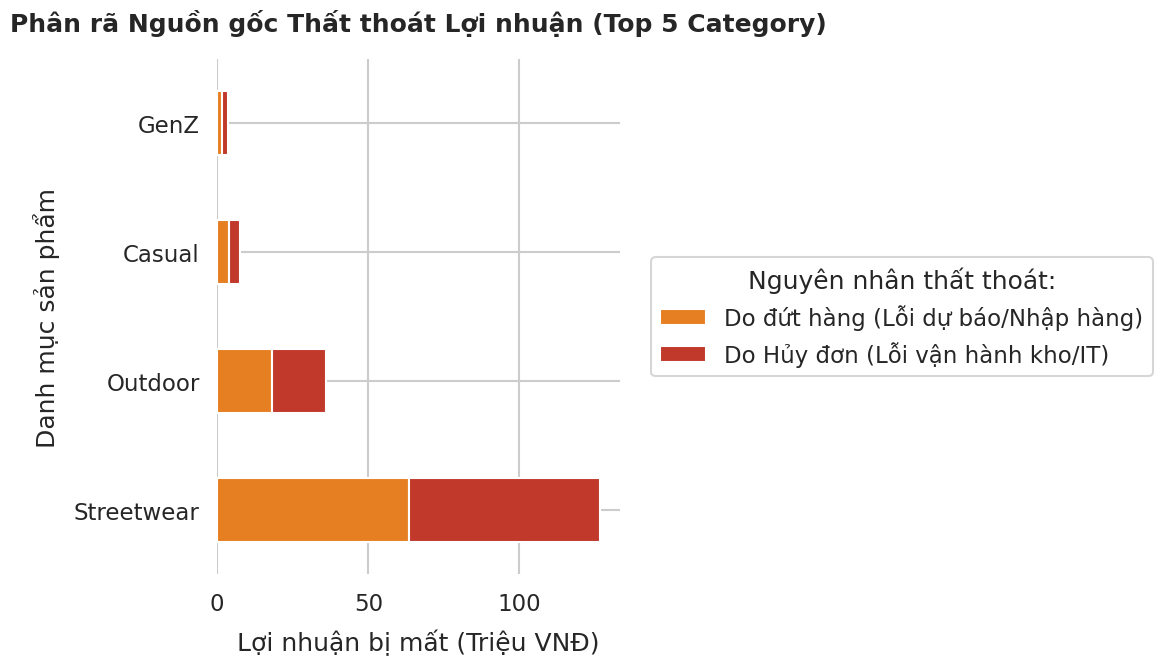

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==========================================
# 1. TÍNH TOÁN TÁCH BẠCH 2 LOẠI THIỆT HẠI
# ==========================================
# (Giả định bạn đã chạy code tính lost_from_fill_rate và lost_from_stockout ở các bước trước)

# Tính ra tiền VNĐ cho từng lỗi
df['lost_profit_fill_rate'] = df['lost_from_fill_rate'] * (df['price'] - df['cogs'])
df['lost_profit_stockout'] = df['lost_from_stockout'] * (df['price'] - df['cogs'])

# Gom nhóm tính tổng theo Category
category_breakdown = df.groupby('category').agg(
    total_lost_profit=('lost_profit', 'sum'),
    lost_due_to_fill_rate=('lost_profit_fill_rate', 'sum'),
    lost_due_to_stockout=('lost_profit_stockout', 'sum')
).reset_index()

# Sắp xếp để lấy Top 5 Category gây thiệt hại tổng lớn nhất
top_5_category = category_breakdown.sort_values(by='total_lost_profit', ascending=False).head(5)

# ==========================================
# 2. VẼ BIỂU ĐỒ CỘT CHỒNG (STACKED BAR CHART)
# ==========================================

# Cài đặt style
sns.set_theme(style="whitegrid", context="talk")

# Để vẽ cột chồng dễ nhất, ta set cột 'category' làm index
plot_data = top_5_category.set_index('category')[['lost_due_to_stockout', 'lost_due_to_fill_rate']]
plot_data = plot_data / 1_000_000

# ==========================================
# 2. VẼ BIỂU ĐỒ CỘT CHỒNG
# ==========================================
sns.set_theme(style="whitegrid", context="talk")

ax = plot_data.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 7),
    color=['#e67e22', '#c0392b']
)

# Trang trí tiêu đề và trục
plt.title("Phân rã Nguồn gốc Thất thoát Lợi nhuận (Top 5 Category)", fontweight='bold', pad=20)
plt.xlabel("Lợi nhuận bị mất (Triệu VNĐ)", labelpad=10) # Đã đổi nhãn trục X
plt.ylabel("Danh mục sản phẩm", labelpad=10)

# ==========================================
# 3. XỬ LÝ LỖI ĐÈ KÝ HIỆU (LEGEND)
# ==========================================
# Sử dụng bbox_to_anchor để đẩy legend ra hẳn mép ngoài bên phải
plt.legend(
    title="Nguyên nhân thất thoát:",
    labels=['Do đứt hàng (Lỗi dự báo/Nhập hàng)', 'Do Hủy đơn (Lỗi vận hành kho/IT)'],
    loc='center left',
    bbox_to_anchor=(1.05, 0.5)
)

sns.despine(left=True, bottom=True)

# Hàm này đảm bảo ảnh khi lưu không bị cắt mất phần legend nằm bên ngoài
plt.tight_layout()
plt.show()



In [7]:
import numpy as np

received_stats = df_inventory.groupby('product_id')['units_received'].agg(['std', 'mean']).reset_index()

# 2. Tính Hệ số biến thiên CV
# Thêm một lượng nhỏ (epsilon) để tránh chia cho 0 nếu mean = 0
received_stats['cv'] = received_stats['std'] / (received_stats['mean'] + 1e-9)

# 3. Phân loại mức độ "Cứng nhắc"
def classify_rigidity(cv):
    if cv == 0: return 'Cố định tuyệt đối (Fixed)'
    if cv < 0.1: return 'Rất ít thay đổi'
    return 'Có điều chỉnh theo nhu cầu'

received_stats['rigidity_type'] = received_stats['cv'].apply(classify_rigidity)

# 4. Xem kết quả tổng quát
print(received_stats['rigidity_type'].value_counts(normalize=True) * 100)

rigidity_type
Có điều chỉnh theo nhu cầu    94.827586
Cố định tuyệt đối (Fixed)      5.172414
Name: proportion, dtype: float64


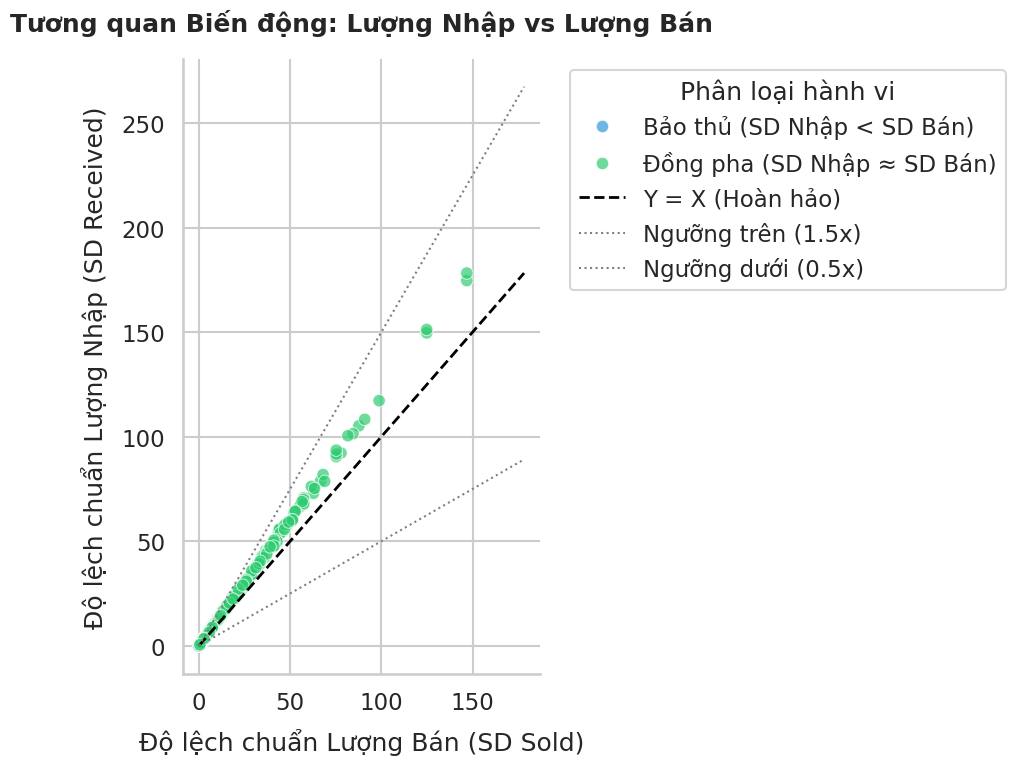

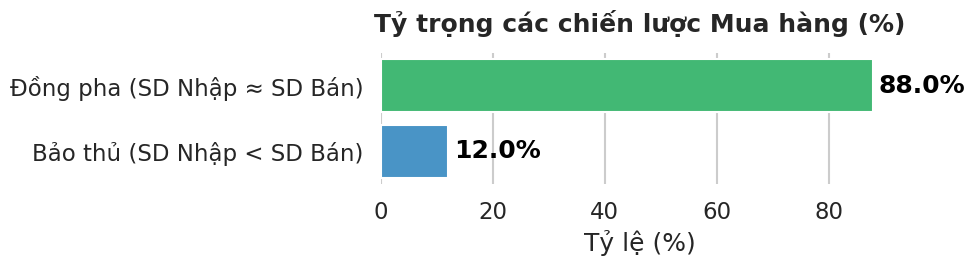

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. TÍNH TOÁN DATA (Giữ nguyên logic cũ)
# ==========================================
# Giả sử df là bảng chứa cột units_received và units_sold
std_comparison = df.groupby('product_id')[['units_received', 'units_sold']].std().reset_index()
std_comparison = std_comparison.fillna(0)
std_comparison['volatility_ratio'] = std_comparison['units_received'] / (std_comparison['units_sold'] + 1e-9)

def classify_behavior(ratio):
    if ratio < 0.5: return 'Bảo thủ (SD Nhập < SD Bán)'
    elif 0.5 <= ratio <= 1.5: return 'Đồng pha (SD Nhập ≈ SD Bán)'
    else: return 'Thái quá (SD Nhập > SD Bán)'

std_comparison['behavior'] = std_comparison['volatility_ratio'].apply(classify_behavior)

# ==========================================
# 2. VẼ BIỂU ĐỒ SCATTER PLOT (PHÂN TÍCH CHUYÊN SÂU)
# ==========================================
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(10, 8))

# Vẽ các điểm
sns.scatterplot(
    data=std_comparison,
    x='units_sold',
    y='units_received',
    hue='behavior',
    palette={
        'Bảo thủ (SD Nhập < SD Bán)': '#3498db', # Xanh dương
        'Đồng pha (SD Nhập ≈ SD Bán)': '#2ecc71', # Xanh lá
        'Thái quá (SD Nhập > SD Bán)': '#e74c3c'  # Đỏ
    },
    alpha=0.7,
    s=80
)

# Kẻ các đường ranh giới toán học
max_val = max(std_comparison['units_sold'].max(), std_comparison['units_received'].max())
x_vals = np.linspace(0, max_val, 100)

plt.plot(x_vals, x_vals, color='black', linestyle='--', linewidth=2, label='Y = X (Hoàn hảo)')
plt.plot(x_vals, 1.5 * x_vals, color='gray', linestyle=':', linewidth=1.5, label='Ngưỡng trên (1.5x)')
plt.plot(x_vals, 0.5 * x_vals, color='gray', linestyle=':', linewidth=1.5, label='Ngưỡng dưới (0.5x)')

plt.title("Tương quan Biến động: Lượng Nhập vs Lượng Bán", fontweight='bold', pad=20)
plt.xlabel("Độ lệch chuẩn Lượng Bán (SD Sold)", labelpad=10)
plt.ylabel("Độ lệch chuẩn Lượng Nhập (SD Received)", labelpad=10)

plt.legend(title="Phân loại hành vi", bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

# ==========================================
# 3. VẼ BIỂU ĐỒ BAR CHART (TỔNG KẾT TỶ LỆ) - ĐÃ FIX WARNING
# ==========================================
plt.figure(figsize=(10, 3))
behavior_counts = std_comparison['behavior'].value_counts(normalize=True) * 100

# Tạo từ điển màu sắc cố định để dù có 2 hay 3 nhóm cũng không bị lỗi
color_map = {
    'Bảo thủ (SD Nhập < SD Bán)': '#3498db', # Xanh dương
    'Đồng pha (SD Nhập ≈ SD Bán)': '#2ecc71', # Xanh lá
    'Thái quá (SD Nhập > SD Bán)': '#e74c3c'  # Đỏ
}

ax = sns.barplot(
    x=behavior_counts.values,
    y=behavior_counts.index,
    hue=behavior_counts.index, # <-- Sửa lỗi hue
    palette=color_map,         # <-- Sửa lỗi thừa màu bằng Dict
    legend=False               # <-- Tắt legend theo yêu cầu của phiên bản mới
)

plt.title("Tỷ trọng các chiến lược Mua hàng (%)", fontweight='bold', pad=15)
plt.xlabel("Tỷ lệ (%)")
plt.ylabel("")
sns.despine(left=True, bottom=True)

# In số % lên từng cột
for i, v in enumerate(behavior_counts.values):
    ax.text(v + 1, i, f"{v:.1f}%", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

--- BẰNG CHỨNG LỆCH BASELINE ---
1. Trung vị lượng hàng nhập DƯ mỗi tháng: +0.3 sản phẩm/mã
2. Tỷ lệ mã hàng bị nhồi dư hàng (Nhập > Bán): 70.9% toàn kho


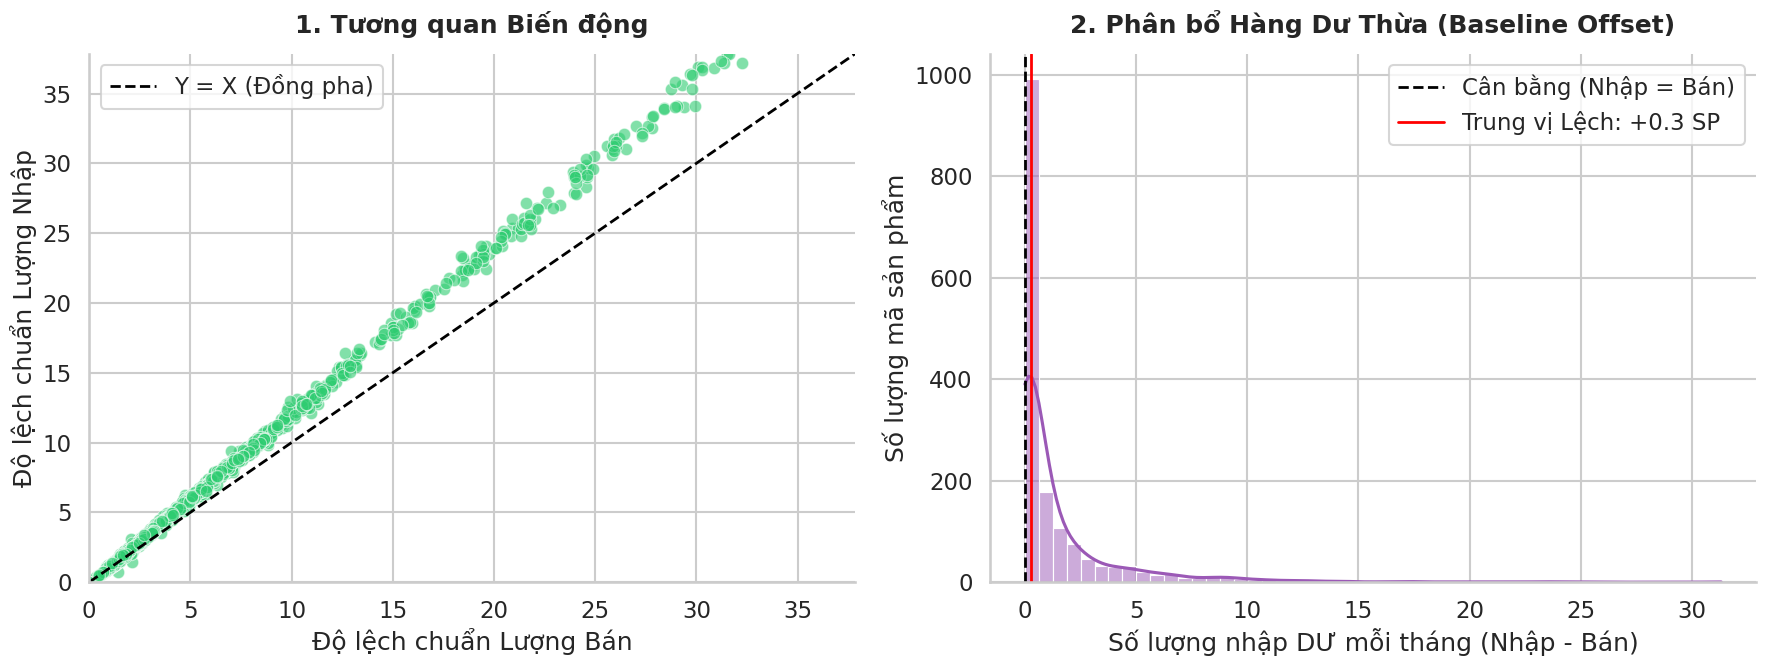

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. TÍNH TOÁN CHỈ SỐ LỆCH BASELINE
# ==========================================
# Tính Trung bình (Mean) và Độ lệch chuẩn (SD)
stats = df.groupby('product_id').agg({
    'units_received': ['mean', 'std'],
    'units_sold': ['mean', 'std']
}).reset_index()

# Làm phẳng tên cột
stats.columns = ['product_id', 'recv_mean', 'recv_std', 'sold_mean', 'sold_std']
stats = stats.fillna(0)

# Đo lường Lệch Baseline (Hàng nhập thừa mỗi tháng)
stats['baseline_offset'] = stats['recv_mean'] - stats['sold_mean']

# In kết quả định lượng để viết Report
offset_median = stats['baseline_offset'].median()
over_recv_percent = (len(stats[stats['baseline_offset'] > 0]) / len(stats)) * 100

print("--- BẰNG CHỨNG LỆCH BASELINE ---")
print(f"1. Trung vị lượng hàng nhập DƯ mỗi tháng: +{offset_median:.1f} sản phẩm/mã")
print(f"2. Tỷ lệ mã hàng bị nhồi dư hàng (Nhập > Bán): {over_recv_percent:.1f}% toàn kho")

# ==========================================
# 2. VẼ BIỂU ĐỒ KÉP (ĐÃ KHẮC PHỤC OUTLIER)
# ==========================================
sns.set_theme(style="whitegrid", context="talk")

# Kính lúp: Chỉ lấy ngưỡng 95% dữ liệu để tránh bị ép dẹt
limit_x = stats['sold_std'].quantile(0.95)
limit_y = stats['recv_std'].quantile(0.95)
max_limit = max(limit_x, limit_y)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Biểu đồ 1: Tương quan SD (Đã Zoom) ---
sns.scatterplot(
    data=stats, x='sold_std', y='recv_std',
    alpha=0.6, color='#2ecc71', s=80, ax=axes[0]
)
# Vẽ đường Y=X
axes[0].plot([0, max_limit], [0, max_limit], color='black', linestyle='--', linewidth=2, label='Y = X (Đồng pha)')
axes[0].set_xlim(0, max_limit)
axes[0].set_ylim(0, max_limit)
axes[0].set_title("1. Tương quan Biến động", fontweight='bold', pad=15)
axes[0].set_xlabel("Độ lệch chuẩn Lượng Bán")
axes[0].set_ylabel("Độ lệch chuẩn Lượng Nhập")
axes[0].legend()

# --- Biểu đồ 2: Phân bổ Baseline Offset ---
sns.histplot(stats['baseline_offset'], bins=50, kde=True, color='#9b59b6', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--', linewidth=2, label='Cân bằng (Nhập = Bán)')
axes[1].axvline(offset_median, color='red', linestyle='-', linewidth=2, label=f'Trung vị Lệch: +{offset_median:.1f} SP')
axes[1].set_title("2. Phân bổ Hàng Dư Thừa (Baseline Offset)", fontweight='bold', pad=15)
axes[1].set_xlabel("Số lượng nhập DƯ mỗi tháng (Nhập - Bán)")
axes[1].set_ylabel("Số lượng mã sản phẩm")
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()

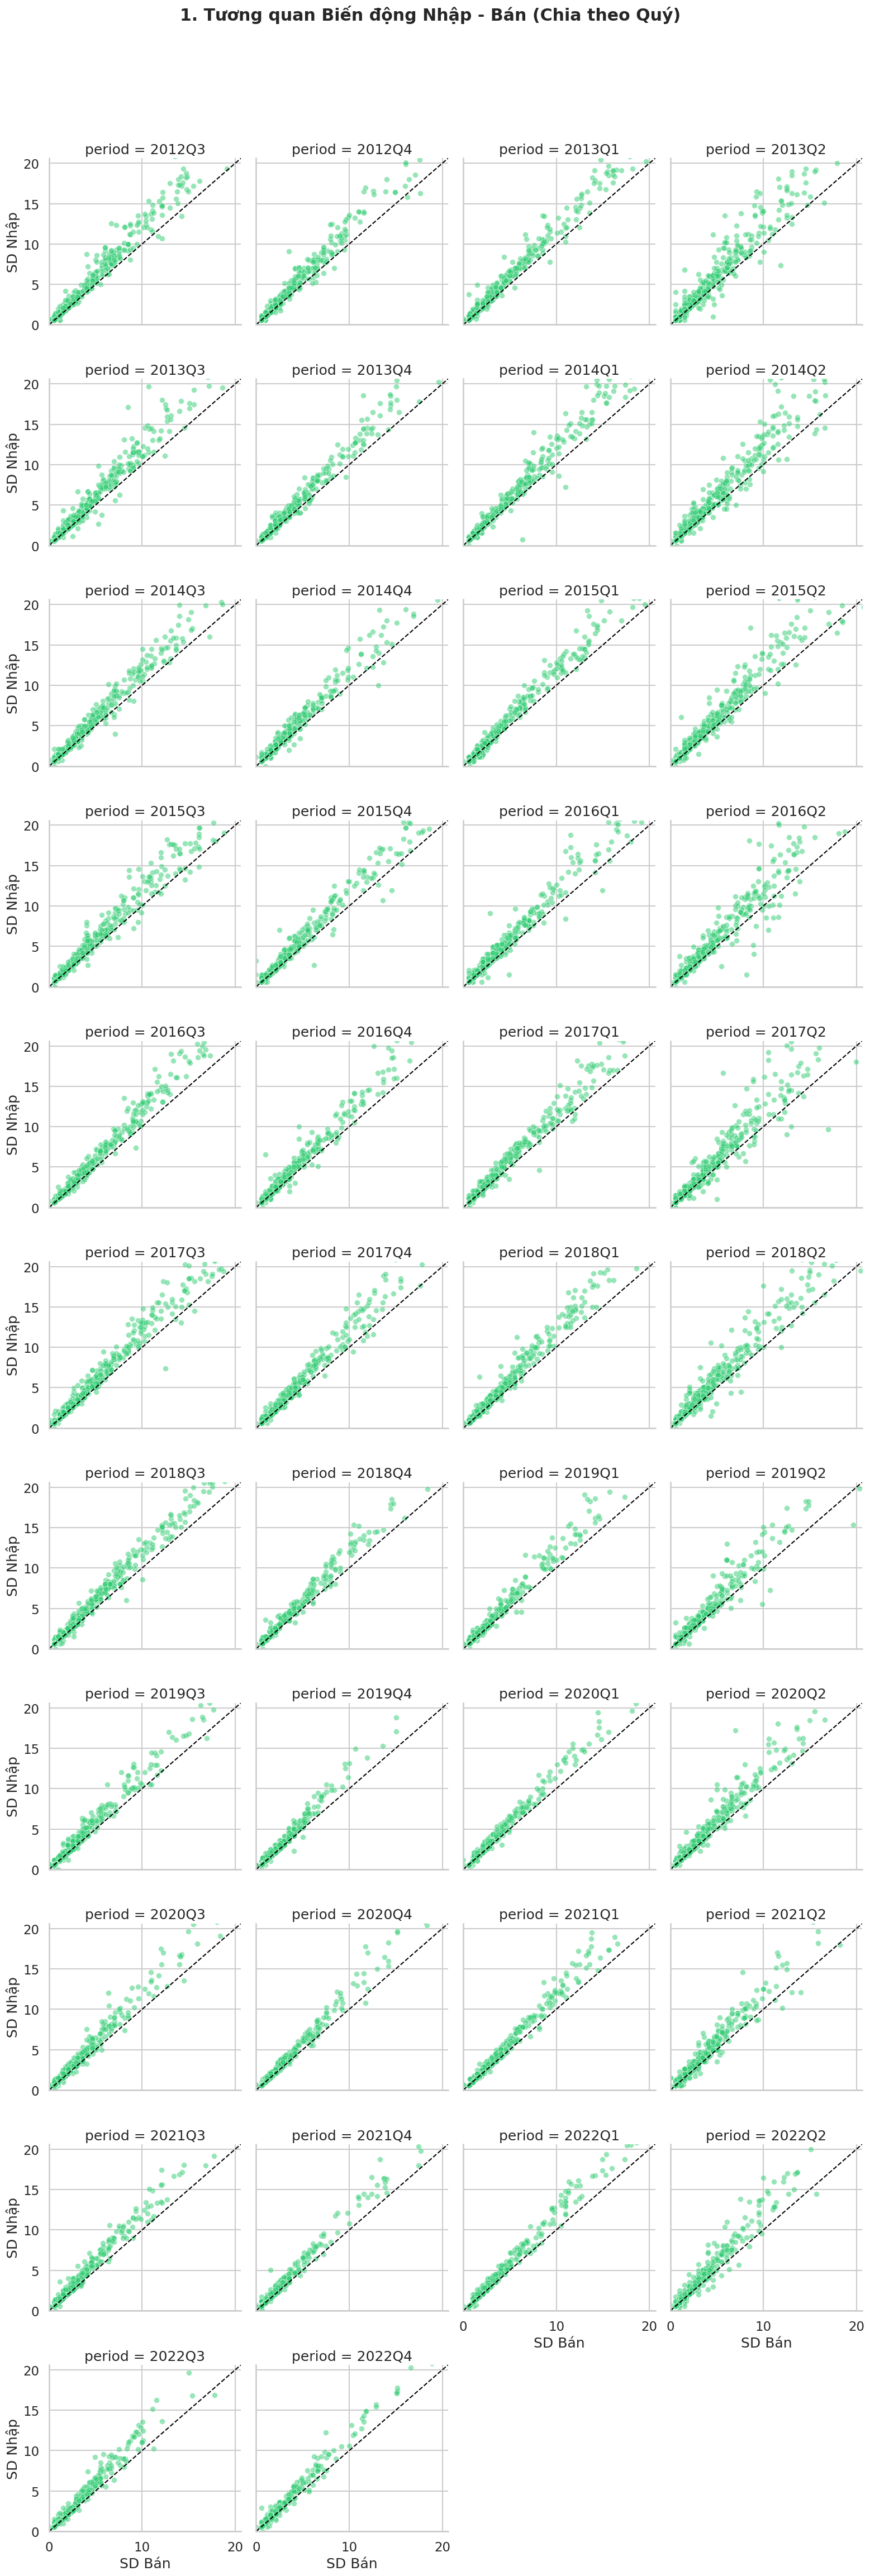

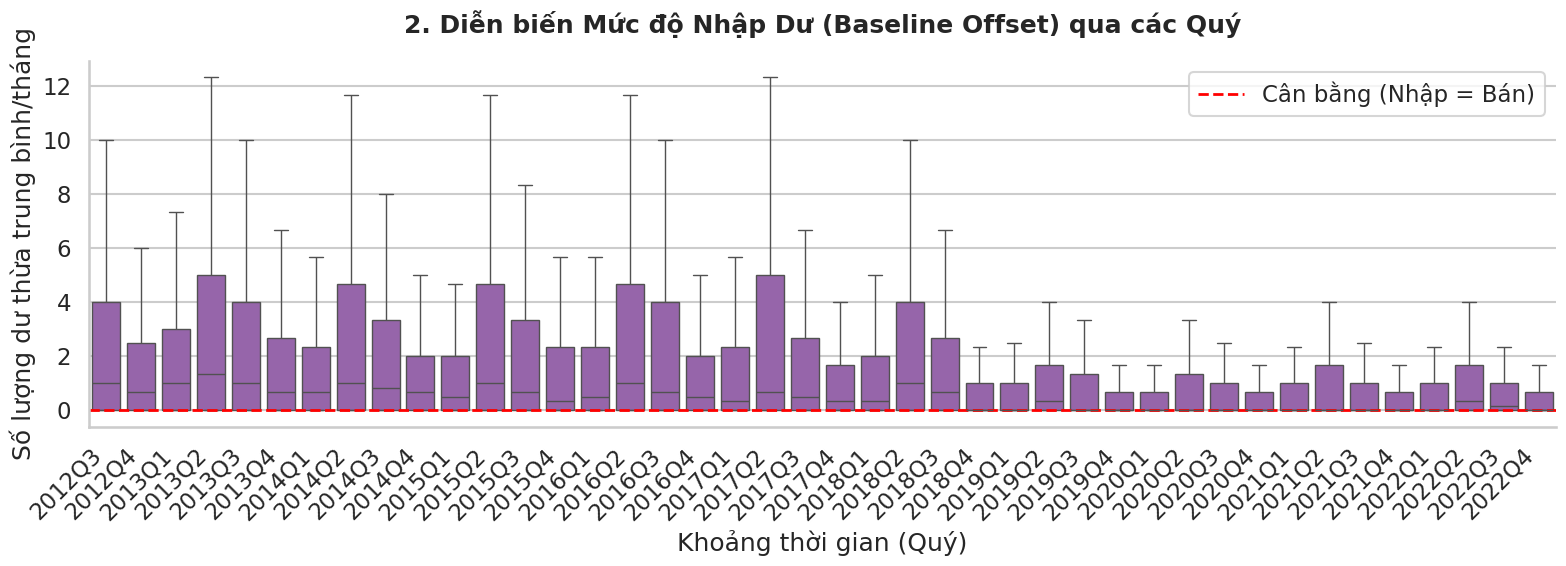

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU & CHIA THEO QUÝ (QUARTER)
# ==========================================
# Đọc và ép kiểu thời gian (Giả định biến df chứa dữ liệu)
inventory = df_inventory.copy() # Sử dụng DataFrame đã tải sẵn
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# Tạo cột Khoảng thời gian (Ví dụ: 2023Q1, 2023Q2)
inventory['period'] = inventory['snapshot_date'].dt.to_period('Q').astype(str)

# Tính Mean, SD và Offset THEO TỪNG QUÝ
stats_time = inventory.groupby(['period', 'product_id']).agg({
    'units_received': ['mean', 'std'],
    'units_sold': ['mean', 'std']
}).reset_index()

stats_time.columns = ['period', 'product_id', 'recv_mean', 'recv_std', 'sold_mean', 'sold_std']
stats_time = stats_time.fillna(0) # Điền 0 nếu quý đó chỉ có 1 tháng có dữ liệu

# Tính Lệch Baseline (Hàng dư thừa)
stats_time['baseline_offset'] = stats_time['recv_mean'] - stats_time['sold_mean']

# Ngưỡng Zoom (Loại 5% Outlier)
limit_x = stats_time['sold_std'].quantile(0.95)
limit_y = stats_time['recv_std'].quantile(0.95)
max_limit = max(limit_x, limit_y)

# ==========================================
# 2. VẼ CHUỖI BIỂU ĐỒ SCATTER (TƯƠNG QUAN THEO QUÝ)
# ==========================================
sns.set_theme(style="whitegrid", context="talk")

# Dùng FacetGrid (relplot) để chia mỗi Quý thành 1 biểu đồ con
g = sns.relplot(
    data=stats_time,
    x='sold_std', y='recv_std',
    col='period', col_wrap=4, # Tối đa 4 biểu đồ 1 hàng (4 Quý)
    color='#2ecc71', alpha=0.5, s=50,
    height=4, aspect=1
)

# Vẽ đường Y=X cho từng biểu đồ con
for ax in g.axes.flat:
    ax.plot([0, max_limit], [0, max_limit], color='black', linestyle='--', linewidth=1.5)
    ax.set_xlim(0, max_limit)
    ax.set_ylim(0, max_limit)

g.fig.suptitle("1. Tương quan Biến động Nhập - Bán (Chia theo Quý)", fontweight='bold', y=1.05)
g.set_axis_labels("SD Bán", "SD Nhập")
plt.show()

# ==========================================
# 3. VẼ BIỂU ĐỒ BOXPLOT (ĐÃ FIX LỖI TRỤC X)
# ==========================================
plt.figure(figsize=(16, 6)) # Tăng chiều dài biểu đồ lên 16 cho rộng rãi

# Đảm bảo dữ liệu được sắp xếp đúng theo dòng thời gian
stats_time = stats_time.sort_values('period')

sns.boxplot(
    data=stats_time,
    x='period', y='baseline_offset',
    color='#9b59b6',
    showfliers=False
)

plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Cân bằng (Nhập = Bán)')

# ---> CÚ FIX LỖI NẰM Ở ĐÂY: Xoay chữ 45 độ và căn lề phải
plt.xticks(rotation=45, ha='right')

plt.title("2. Diễn biến Mức độ Nhập Dư (Baseline Offset) qua các Quý", fontweight='bold', pad=20)
plt.xlabel("Khoảng thời gian (Quý)")
plt.ylabel("Số lượng dư thừa trung bình/tháng")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [11]:
# ==============================================================================
# PHẦN 1: TÍNH TOÁN DỮ LIỆU TỒN KHO & TIỀN CHÔN VỐN
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Đọc và gộp dữ liệu
# Sử dụng các DataFrame đã được tải sẵn trong kernel (df_inventory, df_products)
inventory = df_inventory.copy()
products = df_products.copy()
inv_prod = pd.merge(inventory, products[['product_id', 'cogs', 'price']], on='product_id', how='left')

# 2. Lọc tháng mới nhất
inv_prod['snapshot_date'] = pd.to_datetime(inv_prod['snapshot_date'])
latest_date = inv_prod['snapshot_date'].max()
current_inventory = inv_prod[inv_prod['snapshot_date'] == latest_date].copy()

# 3. Tính toán số lượng và tiền chôn vốn (Target = 45 ngày)
TARGET_DAYS = 45
valid_mask = (current_inventory['days_of_supply'] > 0) & (current_inventory['days_of_supply'] != np.inf)
df_valid = current_inventory[valid_mask].copy()

df_valid['daily_sales'] = df_valid['stock_on_hand'] / df_valid['days_of_supply']
df_valid['excess_qty'] = np.where(
    df_valid['days_of_supply'] > TARGET_DAYS,
    df_valid['daily_sales'] * (df_valid['days_of_supply'] - TARGET_DAYS),
    0
).round(0)
df_valid['tied_up_capital'] = df_valid['excess_qty'] * df_valid['cogs']

# In báo cáo tổng quan (Đã sửa thành VNĐ)
print("=" * 45)
print(f"BÁO CÁO TỒN KHO DƯ THỪA (Tháng: {latest_date.date()})")
print(f"Tổng tiền chôn vốn: {df_valid['tied_up_capital'].sum():,.0f} VNĐ")
print("=" * 45)


BÁO CÁO TỒN KHO DƯ THỪA (Tháng: 2022-12-31)
Tổng tiền chôn vốn: 365,077,798 VNĐ



--- PHÂN LOẠI MỨC ĐỘ ƯU TIÊN GIẢI CỨU (K-MEANS) ---


,Priority_Label,Số_lượng_Mã_SP,Tổng_Sản_phẩm_Dư,Tổng_Tiền_Chôn_vốn
0,1. Xả gấp (Đỏ),11,"16,870","122,368,838 VNĐ"
1,2. Ưu tiên cao (Cam),21,"28,503","52,473,260 VNĐ"
2,3. Theo dõi (Xanh dương),73,"37,634","114,437,649 VNĐ"
3,4. Bỏ qua (Xanh lá),319,"16,201","75,798,052 VNĐ"


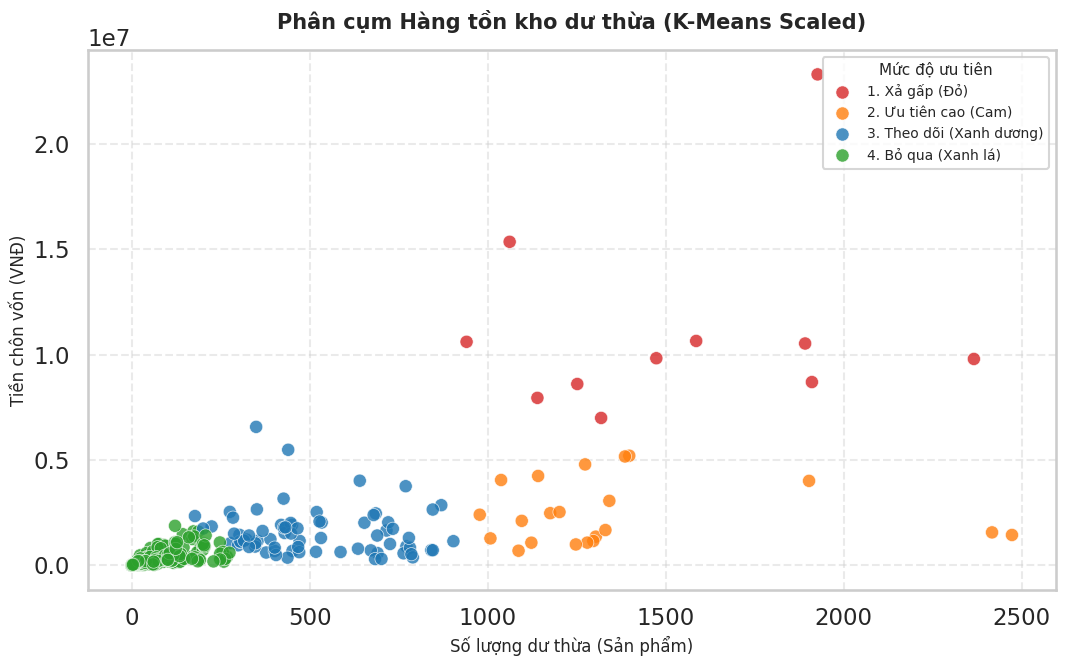

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# ==============================================================================
# PHẦN 3.1: CHẠY THUẬT TOÁN K-MEANS CHUẨN MỰC
# ==============================================================================
# 1. Lọc ra 2 biến cần phân cụm
features = df_valid[['excess_qty', 'tied_up_capital']]

# 2. CHUẨN HÓA DỮ LIỆU (Bước sống còn để không bị lệch trục)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# 3. Áp dụng K-Means với 4 cụm (clusters)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_valid['Cluster_ID'] = kmeans.fit_predict(features_scaled)

# 4. Tự động gắn nhãn (Màu sắc) dựa trên "Độ nghiêm trọng" của Cụm
# Cụm nào có tâm (centroid) càng xa gốc tọa độ (0,0) thì càng nguy hiểm
centroids = kmeans.cluster_centers_
severity = np.linalg.norm(centroids, axis=1) # Tính khoảng cách từ tâm tới gốc 0
sorted_clusters = np.argsort(severity)[::-1] # Sắp xếp từ nguy hiểm nhất đến an toàn nhất

label_mapping = {
    sorted_clusters[0]: '1. Xả gấp (Đỏ)',
    sorted_clusters[1]: '2. Ưu tiên cao (Cam)',
    sorted_clusters[2]: '3. Theo dõi (Xanh dương)',
    sorted_clusters[3]: '4. Bỏ qua (Xanh lá)'
}

df_valid['Priority_Label'] = df_valid['Cluster_ID'].map(label_mapping)

# ==============================================================================
# PHẦN 3.2: HIỂN THỊ KẾT QUẢ VÀ VẼ BIỂU ĐỒ (Giữ nguyên code của bạn)
# ==============================================================================
# In bảng thống kê
print("\n--- PHÂN LOẠI MỨC ĐỘ ƯU TIÊN GIẢI CỨU (K-MEANS) ---")
final_report = df_valid.groupby('Priority_Label').agg(
    Số_lượng_Mã_SP=('product_id', 'nunique'),
    Tổng_Sản_phẩm_Dư=('excess_qty', 'sum'),
    Tổng_Tiền_Chôn_vốn=('tied_up_capital', 'sum')
).reset_index()

final_report = final_report.sort_values(by='Priority_Label')
final_report['Tổng_Tiền_Chôn_vốn'] = final_report['Tổng_Tiền_Chôn_vốn'].apply(lambda x: f"{x:,.0f} VNĐ")
final_report['Tổng_Sản_phẩm_Dư'] = final_report['Tổng_Sản_phẩm_Dư'].apply(lambda x: f"{x:,.0f}")
display(final_report)

# Vẽ biểu đồ
plt.figure(figsize=(11, 7))

label_order = ['1. Xả gấp (Đỏ)', '2. Ưu tiên cao (Cam)', '3. Theo dõi (Xanh dương)', '4. Bỏ qua (Xanh lá)']
colors = {'1. Xả gấp (Đỏ)': '#d62728', '2. Ưu tiên cao (Cam)': '#ff7f0e', '3. Theo dõi (Xanh dương)': '#1f77b4', '4. Bỏ qua (Xanh lá)': '#2ca02c'}

sns.scatterplot(
    data=df_valid, x='excess_qty', y='tied_up_capital',
    hue='Priority_Label', hue_order=label_order, palette=colors,
    s=90, alpha=0.8, edgecolor='w', linewidth=0.5
)

plt.title('Phân cụm Hàng tồn kho dư thừa (K-Means Scaled)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Số lượng dư thừa (Sản phẩm)', fontsize=12)
plt.ylabel('Tiền chôn vốn (VNĐ)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Mức độ ưu tiên', title_fontsize='11', fontsize='10')
plt.tight_layout()
plt.show()

✅ Đang sử dụng dữ liệu Tồn kho làm Trục thời gian.
🔍 Dựa trên dữ liệu, Mã sản phẩm bị đứt hàng nghiêm trọng nhất (Top Culprit) là: 1009


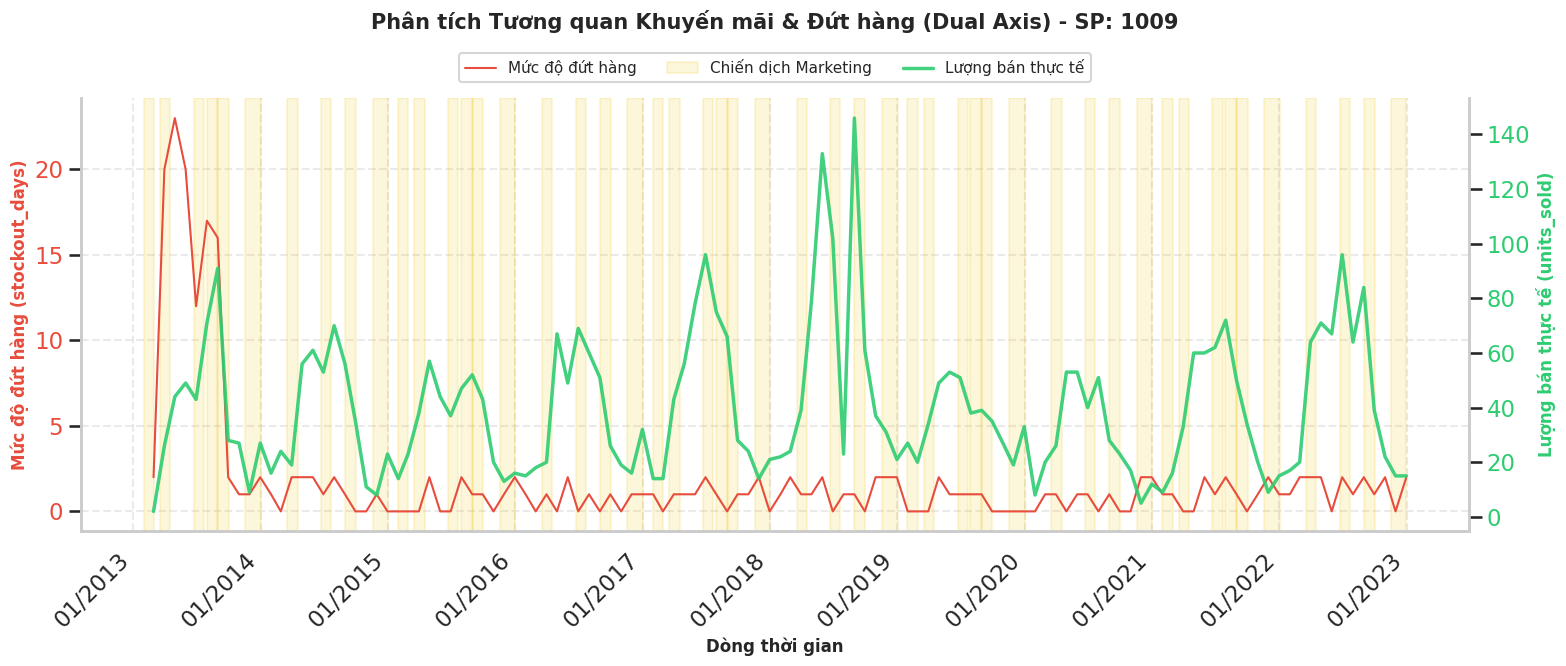

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# ==============================================================================
# PHẦN 1: CHUẨN BỊ DỮ LIỆU & TẠO TRỤC THỜI GIAN (CLEAN CODE)
# ==============================================================================
# 1. Xử lý bảng Khuyến mãi (Điền 'All' cho các Category bị Null)
promotions = df_promotions.copy()
promotions['start_date'] = pd.to_datetime(promotions['start_date']).dt.date
promotions['end_date'] = pd.to_datetime(promotions['end_date']).dt.date
promotions['applicable_category'] = promotions['applicable_category'].fillna('All')

# 2. Xử lý Dữ liệu phân tích & Định nghĩa 'time_axis' chuẩn logic
if 'df' in globals():
    analysis_df = df.copy()
    # Nếu đã chạy bảng Tồn kho (df), ta dùng snapshot_date làm trục thời gian
    analysis_df['time_axis'] = pd.to_datetime(analysis_df['snapshot_date']).dt.date
    print("✅ Đang sử dụng dữ liệu Tồn kho làm Trục thời gian.")
else:
    # Nếu chưa, ta dùng bảng Đơn hàng làm phương án thay thế
    analysis_df = df_orders.copy()
    analysis_df['time_axis'] = pd.to_datetime(analysis_df['order_date']).dt.date
    print("✅ Đang sử dụng dữ liệu Đơn hàng làm Trục thời gian.")

# ==============================================================================
# PHẦN 2: TRUY TÌM TỘI ĐỒ & GOM NHÓM THEO TIME_AXIS
# ==============================================================================

# LOGIC LỰA CHỌN: Tự động quét toàn bộ dữ liệu, nhóm theo từng mã sản phẩm,
# tính tổng số ngày đứt hàng (stockout_days) và bốc ra mã có tổng cao nhất.
top_culprit_id = analysis_df.groupby('product_id')['stockout_days'].sum().idxmax()

print(f"🔍 Dựa trên dữ liệu, Mã sản phẩm bị đứt hàng nghiêm trọng nhất (Top Culprit) là: {top_culprit_id}")

# Lọc riêng dữ liệu của mã sản phẩm 'tội đồ' này
target_product_data = analysis_df[analysis_df['product_id'] == top_culprit_id]

# Gom nhóm theo TRỤC THỜI GIAN CHUNG (time_axis) để tính tổng bán & đứt hàng
daily_stats = target_product_data.groupby('time_axis').agg({
    'units_sold': 'sum',
    'stockout_days': 'sum'
}).reset_index()

# Đảm bảo dữ liệu được sắp xếp xuôi dòng thời gian
daily_stats = daily_stats.sort_values('time_axis')

# ==============================================================================
# PHẦN 3: VẼ BIỂU ĐỒ 2 TRỤC Y (DUAL AXIS CHART)
# ==============================================================================
sns.set_theme(style="whitegrid", context="talk")
fig, ax1 = plt.subplots(figsize=(16, 7))

# --- TRỤC Y TRÁI (ax1): MỨC ĐỘ ĐỨT HÀNG (ĐƯỜNG MÀU ĐỎ) ---
color_red = '#e74c3c'
ax1.set_xlabel('Dòng thời gian', fontweight='bold', fontsize=12)
ax1.set_ylabel('Mức độ đứt hàng (stockout_days)', color=color_red, fontweight='bold', fontsize=12)

ax1.plot(daily_stats['time_axis'], daily_stats['stockout_days'],
         color=color_red, label='Mức độ đứt hàng', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color_red)

# Tô nền vàng cho các Chiến dịch Marketing
promo_flag = False
for _, promo in promotions.iterrows():
    ax1.axvspan(promo['start_date'], promo['end_date'],
                color='#f1c40f', alpha=0.15,
                label='Chiến dịch Marketing' if not promo_flag else "")
    promo_flag = True

# --- TRỤC Y PHẢI (ax2): LƯỢNG BÁN THỰC TẾ (ĐƯỜNG MÀU XANH LÁ) ---
ax2 = ax1.twinx()  # CÚ PHÁP TẠO TRỤC Y THỨ 2 DÙNG CHUNG TRỤC X
color_green = '#2ecc71'
ax2.set_ylabel('Lượng bán thực tế (units_sold)', color=color_green, fontweight='bold', fontsize=12)

ax2.plot(daily_stats['time_axis'], daily_stats['units_sold'],
         color=color_green, label='Lượng bán thực tế', linewidth=2.5, alpha=0.9)
ax2.tick_params(axis='y', labelcolor=color_green)

# --- TRANG TRÍ VÀ HIỂN THỊ ---
# Gom chú thích của 2 trục và đưa lên TRÊN CÙNG, dàn ngang 3 cột (ncol=3)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc='lower center', bbox_to_anchor=(0.5, 1.02),
           ncol=3, frameon=True, fontsize=11)

# Định dạng ngày tháng trục X cho đỡ rối
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
fig.autofmt_xdate(rotation=45)

# Tùy chỉnh lưới (Chỉ bật lưới ngang cho trục trái)
ax1.grid(True, linestyle='--', alpha=0.4)
ax2.grid(False)

# Tăng khoảng cách pad=40 để chừa chỗ trống cho cái Legend nằm phía trên
plt.title(f'Phân tích Tương quan Khuyến mãi & Đứt hàng (Dual Axis) - SP: {top_culprit_id}',
          fontweight='bold', fontsize=15, pad=50)

sns.despine(right=False) # Giữ lại viền khung bên phải cho ax2
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import numpy as np

# ==============================================================================
# BƯỚC 0: ĐỌC DỮ LIỆU TỪ FILE CSV
# ==============================================================================
df_orders = df_orders.copy()
df_customers = df_customers.copy()
df_promotions = df_promotions.copy()

print("✅ Bước 0: Đã load dữ liệu thành công!")

# ==============================================================================
# BƯỚC 1: TIỀN XỬ LÝ & LỌC ĐƠN HÀNG THÀNH CÔNG
# ==============================================================================
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_customers['signup_date'] = pd.to_datetime(df_customers['signup_date'])
df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])

# Lọc riêng các đơn hàng thành công để làm căn cứ tính ngày mua hàng
successful_orders = df_orders[df_orders['order_status'].str.lower().isin(['completed', 'delivered'])]

# Ghép ngày đăng ký vào bảng phân tích
df_analysis = pd.merge(df_orders, df_customers[['customer_id', 'signup_date']], on='customer_id', how='left')

print("✅ Bước 1: Đã chuẩn bị xong dữ liệu nền!")

# ==============================================================================
# BƯỚC 2: TÁCH 4 NHÓM KHÁCH HÀNG (NÂNG CẤP TÌM KHÁCH HỒI SINH)
# ==============================================================================
# 1. Gắn mã Promotion cho toàn bộ đơn hàng
df_analysis['promo_id'] = 'No_Promo'

for _, promo in df_promotions.iterrows():
    mask = (df_analysis['order_date'] >= promo['start_date']) & (df_analysis['order_date'] <= promo['end_date'])
    # Nhớ đổi 'promotion_id' cho khớp với tên cột của bạn nếu bị lỗi KeyError
    df_analysis.loc[mask, 'promo_id'] = promo['promo_id']

# Tìm Top 3 Promotions
top_3_promos = df_analysis[df_analysis['promo_id'] != 'No_Promo']['promo_id'].value_counts().head(3).index.tolist()
print(f"🏆 Top 3 Promotions lớn nhất là: {top_3_promos}")

# 2. Xử lý tính toán động "Ngày mua gần nhất" cho TỪNG đợt Promotion
promo_data_list = []

for promo_id in top_3_promos:
    # Lấy ngày bắt đầu của Promotion này
    promo_start = df_promotions.loc[df_promotions['promo_id'] == promo_id, 'start_date'].values[0]
    promo_start = pd.to_datetime(promo_start)

    # TRÍCH XUẤT LỊCH SỬ: Tìm ngày mua gần nhất của mỗi khách TÍNH ĐẾN TRƯỚC ngày Sale bắt đầu
    past_orders = successful_orders[successful_orders['order_date'] < promo_start]
    last_orders = past_orders.groupby('customer_id')['order_date'].max().reset_index()
    last_orders.rename(columns={'order_date': 'last_order_before_promo'}, inplace=True)

    # Lọc đơn hàng thuộc đợt Sale này
    curr_promo_orders = df_analysis[df_analysis['promo_id'] == promo_id].copy()

    # Ghép lịch sử mua vào để đối chiếu
    curr_promo_orders = curr_promo_orders.merge(last_orders, on='customer_id', how='left')
    curr_promo_orders['promo_start'] = promo_start

    promo_data_list.append(curr_promo_orders)

# Gộp dữ liệu của cả 3 chiến dịch lại để xử lý 1 lần
df_top3 = pd.concat(promo_data_list, ignore_index=True)

# 3. Tính khoảng cách "Đóng băng" (Số ngày kể từ lần mua cuối đến lúc Sale)
df_top3['last_order_before_promo'] = pd.to_datetime(df_top3['last_order_before_promo'])
df_top3['days_since_last_order'] = (df_top3['promo_start'] - df_top3['last_order_before_promo']).dt.days

# 4. LUẬT RẼ NHÁNH 4 NHÓM KHÁCH HÀNG CHUYÊN SÂU (ĐÃ FIX LỖI LOGIC)
conditions = [
    # Ưu tiên kiểm tra KHÁCH CŨ (last_order_before_promo KHÔNG NULL)
    # Nhóm 3: Khách Hồi Sinh (Bỏ đi HƠN 90 NGÀY)
    (df_top3['last_order_before_promo'].notnull()) & (df_top3['days_since_last_order'] > 90),

    # Nhóm 4: Khách Quen (Mới mua cách đây TỪ 90 NGÀY TRỞ XUỐNG)
    (df_top3['last_order_before_promo'].notnull()) & (df_top3['days_since_last_order'] <= 90),

    # Sau đó mới xét KHÁCH MỚI (Bắt buộc last_order_before_promo phải LÀ NULL)
    # Nhóm 1: New Star
    (df_top3['last_order_before_promo'].isnull()) & (df_top3['signup_date'].notnull()) & (df_top3['signup_date'] >= df_top3['promo_start']),

    # Nhóm 2: Awakened Zombie
    (df_top3['last_order_before_promo'].isnull()) & (df_top3['signup_date'].notnull()) & (df_top3['signup_date'] < df_top3['promo_start'])
]

# Đảm bảo thứ tự choices khớp với thứ tự conditions ở trên
choices = ['3. Khách Hồi Sinh (>90 ngày)', '4. Khách Quen (<=90 ngày)', '1. New Star', '2. Awakened Zombie']

df_top3['Customer_Segment'] = np.select(conditions, choices, default='Unknown')

# Thêm số 1, 2, 3, 4 ở trước để bảng in ra sắp xếp theo thứ tự cho đẹp
choices = ['1. New Star', '2. Awakened Zombie', '3. Khách Hồi Sinh (>90 ngày)', '4. Khách Quen (<=90 ngày)']

df_top3['Customer_Segment'] = np.select(conditions, choices, default='Unknown')

# ==============================================================================
# BƯỚC 3: XUẤT BÁO CÁO CẤU TRÚC 4 NHÓM
# ==============================================================================
segment_report = df_top3.groupby(['promo_id', 'Customer_Segment']).size().unstack(fill_value=0)
segment_report_pct = segment_report.div(segment_report.sum(axis=1), axis=0) * 100

print("\n📊 BÁO CÁO CẤU TRÚC 4 NHÓM KHÁCH HÀNG TOP 3 PROMOTIONS (%):")
print(segment_report_pct.round(2))

✅ Bước 0: Đã load dữ liệu thành công!
✅ Bước 1: Đã chuẩn bị xong dữ liệu nền!
🏆 Top 3 Promotions lớn nhất là: ['PROMO-0014', 'PROMO-0011', 'PROMO-0010']

📊 BÁO CÁO CẤU TRÚC 4 NHÓM KHÁCH HÀNG TOP 3 PROMOTIONS (%):
Customer_Segment  1. New Star  2. Awakened Zombie  \
promo_id                                            
PROMO-0010              55.16               28.58   
PROMO-0011              59.19               24.32   
PROMO-0014              57.31               32.18   

Customer_Segment  3. Khách Hồi Sinh (>90 ngày)  4. Khách Quen (<=90 ngày)  
promo_id                                                                   
PROMO-0010                               15.35                       0.91  
PROMO-0011                               15.15                       1.34  
PROMO-0014                                9.27                       1.24  


In [15]:
import pandas as pd

# Giả sử df_orders của bạn đã được load sẵn
# df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# 1. Chỉ lấy những đơn hàng thành công
df_success = df_orders[df_orders['order_status'].str.lower().isin(['completed', 'delivered'])].copy()

# 2. Sắp xếp dữ liệu theo Khách hàng và Ngày mua (theo thứ tự thời gian từ cũ đến mới)
df_success = df_success.sort_values(['customer_id', 'order_date'])

# 3. Dùng thủ thuật dịch dòng (shift) để mang "Ngày mua lần trước" đặt cạch "Ngày mua lần này"
df_success['prev_order_date'] = df_success.groupby('customer_id')['order_date'].shift(1)

# 4. Tính khoảng cách số ngày giữa 2 lần mua liên tiếp
df_success['days_between'] = (df_success['order_date'] - df_success['prev_order_date']).dt.days

# 5. Lọc bỏ các dòng trống (đơn đầu tiên không có ngày mua trước đó)
# và các trường hợp mua 2 đơn cùng 1 ngày (days_between = 0)
valid_gaps = df_success[df_success['days_between'] > 0]['days_between']

# 6. Tính toán con số thống kê
mean_tbp = valid_gaps.mean()
median_tbp = valid_gaps.median()

print("📊 KẾT QUẢ ĐO LƯỜNG NHỊP ĐỘ MUA SẮM:")
print(f"Khoảng thời gian mua lại Trung bình (Mean): {mean_tbp:.1f} ngày")
print(f"Khoảng thời gian mua lại Phổ biến nhất (Median): {median_tbp:.1f} ngày")

# Đề xuất mốc Churn (Khách rời bỏ) an toàn là Gấp đôi (x2) thời gian Median
churn_threshold = median_tbp * 2
print(f"\n💡 ĐỀ XUẤT CHO BẠN:")
print(f"Thay vì dùng mốc 90 ngày mặc định, hãy dùng mốc {churn_threshold:.0f} ngày làm chuẩn!")

📊 KẾT QUẢ ĐO LƯỜNG NHỊP ĐỘ MUA SẮM:
Khoảng thời gian mua lại Trung bình (Mean): 327.6 ngày
Khoảng thời gian mua lại Phổ biến nhất (Median): 178.0 ngày

💡 ĐỀ XUẤT CHO BẠN:
Thay vì dùng mốc 90 ngày mặc định, hãy dùng mốc 356 ngày làm chuẩn!


In [16]:
import pandas as pd
import numpy as np

# ==============================================================================
# BƯỚC 0: ĐỌC DỮ LIỆU
# ==============================================================================
df_orders = pd.read_csv('./dataset/orders.csv')
df_items = pd.read_csv('./dataset/order_items.csv')

# ==============================================================================
# BƯỚC 1: TÍNH DOANH THU & XÁC ĐỊNH KHUYẾN MÃI TỪ CHI TIẾT ĐƠN HÀNG
# ==============================================================================
# 1. Tính doanh thu của từng dòng sản phẩm (Số lượng x Đơn giá đã giảm)
df_items['line_revenue'] = df_items['quantity'] * df_items['unit_price']

# 2. Xác định xem dòng sản phẩm này có dùng mã Sale nào không?
# Trả về True nếu cột promo_id HOẶC promo_id_2 có chứa dữ liệu
df_items['is_promo_item'] = df_items['promo_id'].notna() | df_items['promo_id_2'].notna()

# 3. Gom nhóm lại theo Đơn hàng (order_id)
order_summary = df_items.groupby('order_id').agg(
    total_revenue=('line_revenue', 'sum'),
    has_promo=('is_promo_item', 'any') # Nếu có ít nhất 1 món dùng Promo -> Cả đơn được tính là Promo
).reset_index()

# ==============================================================================
# BƯỚC 2: GHÉP VỚI BẢNG ORDERS & PHÂN LOẠI
# ==============================================================================
# Ghép thông tin doanh thu vào bảng đơn hàng gốc
df_full = df_orders.merge(order_summary, on='order_id', how='left')

# Lọc các đơn hàng thành công
successful_orders = df_full[df_full['order_status'].str.lower().isin(['completed', 'delivered'])].copy()

# Dán nhãn Đơn Promo và Đơn Giá Gốc
successful_orders['Order_Type'] = np.where(
    successful_orders['has_promo'],
    'Promotional (Có Khuyến Mãi)',
    'Non-Promo (Giá Gốc)'
)

# ==============================================================================
# BƯỚC 3: XUẤT BÁO CÁO "ĐỘ NGHIỆN SALE"
# ==============================================================================
# Số lượng đơn
order_counts = successful_orders['Order_Type'].value_counts()
order_pct = (order_counts / order_counts.sum()) * 100

# Doanh thu
revenue_sums = successful_orders.groupby('Order_Type')['total_revenue'].sum()
revenue_pct = (revenue_sums / revenue_sums.sum()) * 100

# AOV
aov = successful_orders.groupby('Order_Type')['total_revenue'].mean()

# Gom thành bảng
report = pd.DataFrame({
    'Số lượng đơn': order_counts,
    'Tỷ trọng Đơn (%)': order_pct.round(2),
    'Tổng Doanh thu': revenue_sums,
    'Tỷ trọng Doanh thu (%)': revenue_pct.round(2),
    'AOV (TB 1 đơn)': aov.round(2)
})

print("\n🚨 BÁO CÁO 'ĐỘ NGHIỆN SALE' CỦA DOANH NGHIỆP:")
print("-" * 80)
print(report)

/tmp/ipykernel_2582/2484644080.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_items = pd.read_csv('./dataset/order_items.csv')



🚨 BÁO CÁO 'ĐỘ NGHIỆN SALE' CỦA DOANH NGHIỆP:
--------------------------------------------------------------------------------
                             Số lượng đơn  Tỷ trọng Đơn (%)  Tổng Doanh thu  \
Order_Type                                                                    
Non-Promo (Giá Gốc)                318494             61.64    8.772027e+09   
Promotional (Có Khuyến Mãi)        198222             38.36    4.345065e+09   

                             Tỷ trọng Doanh thu (%)  AOV (TB 1 đơn)  
Order_Type                                                           
Non-Promo (Giá Gốc)                           66.87        27542.20  
Promotional (Có Khuyến Mãi)                   33.13        21920.19  


In [17]:
import pandas as pd
import numpy as np

# ==============================================================================
# BƯỚC 0: ĐỌC VÀ CHUẨN BỊ 4 BẢNG DỮ LIỆU
# ==============================================================================
# Giả sử bạn đọc dữ liệu từ file (hoặc copy từ biến có sẵn)
# df_orders = pd.read_csv('orders.csv')
# df_customers = pd.read_csv('customers.csv')
# df_promotions = pd.read_csv('promotions.csv')
# df_items = pd.read_csv('order_items.csv')

df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_customers['signup_date'] = pd.to_datetime(df_customers['signup_date'])
df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])

successful_orders = df_orders[df_orders['order_status'].str.lower().isin(['completed', 'delivered'])].copy()

# ==============================================================================
# BƯỚC 1: XÁC ĐỊNH MÃ PROMO THỰC TẾ TỪ CHI TIẾT GIỎ HÀNG
# ==============================================================================
# Lọc các dòng sản phẩm có dùng mã và tìm mã chính cho từng đơn
promo_items = df_items[df_items['promo_id'].notna()].copy()
order_promo_truth = promo_items.groupby('order_id')['promo_id'].first().reset_index()
order_promo_truth.rename(columns={'promo_id': 'Actual_Promo_Used'}, inplace=True)

# Ghép Sự thật này vào bảng phân tích
df_analysis = pd.merge(successful_orders, order_promo_truth, on='order_id', how='left')
df_analysis = pd.merge(df_analysis, df_customers[['customer_id', 'signup_date']], on='customer_id', how='left')

# Các đơn không ghép được mã (NaN) -> Đích thị là đơn Giá Gốc
df_analysis['Actual_Promo_Used'] = df_analysis['Actual_Promo_Used'].fillna('No_Promo')

# Lấy Top 10 Promo CÓ SỐ LƯỢNG SỬ DỤNG MÃ thực tế cao nhất
top_10_promos = df_analysis[df_analysis['Actual_Promo_Used'] != 'No_Promo']['Actual_Promo_Used'].value_counts().head(10).index.tolist()

# ==============================================================================
# BƯỚC 2: XÂY DỰNG LỊCH SỬ KHÁCH HÀNG CHO TỪNG CHIẾN DỊCH
# ==============================================================================
CHURN_THRESHOLD = 356
promo_data_list = []

for promo_id in top_10_promos:
    # Lấy ngày bắt đầu của chiến dịch để làm cột mốc thời gian
    promo_start = df_promotions.loc[df_promotions['promo_id'] == promo_id, 'start_date'].values[0]
    promo_start = pd.to_datetime(promo_start)

    # Quét toàn bộ đơn hàng của công ty TÍNH ĐẾN TRƯỚC ngày Promo này chạy
    past_orders = successful_orders[successful_orders['order_date'] < promo_start]
    last_orders = past_orders.groupby('customer_id')['order_date'].max().reset_index()
    last_orders.rename(columns={'order_date': 'last_order_before_promo'}, inplace=True)

    # Chỉ bốc những đơn hàng CHẮC CHẮN có xài mã Promo này ra để phân tích
    curr_promo_orders = df_analysis[df_analysis['Actual_Promo_Used'] == promo_id].copy()
    curr_promo_orders = curr_promo_orders.merge(last_orders, on='customer_id', how='left')
    curr_promo_orders['promo_start'] = promo_start

    promo_data_list.append(curr_promo_orders)

df_all_promos = pd.concat(promo_data_list, ignore_index=True)

# ==============================================================================
# BƯỚC 3: PHÂN LOẠI 4 NHÓM KHÁCH HÀNG (SỰ THẬT TUYỆT ĐỐI)
# ==============================================================================
df_all_promos['last_order_before_promo'] = pd.to_datetime(df_all_promos['last_order_before_promo'])
df_all_promos['days_since_last_order'] = (df_all_promos['promo_start'] - df_all_promos['last_order_before_promo']).dt.days

conditions = [
    # Nhóm 3: Khách Hồi Sinh (Bỏ đi HƠN 356 NGÀY)
    (df_all_promos['last_order_before_promo'].notnull()) & (df_all_promos['days_since_last_order'] > CHURN_THRESHOLD),

    # Nhóm 4: Khách Quen (Mới mua cách đây TỪ 356 NGÀY TRỞ XUỐNG)
    (df_all_promos['last_order_before_promo'].notnull()) & (df_all_promos['days_since_last_order'] <= CHURN_THRESHOLD),

    # Nhóm 1: New Star (Chưa từng mua + Đăng ký trong/sau khi Sale bắt đầu)
    (df_all_promos['last_order_before_promo'].isnull()) & (df_all_promos['signup_date'].notnull()) & (df_all_promos['signup_date'] >= df_all_promos['promo_start']),

    # Nhóm 2: Awakened Zombie (Chưa từng mua + Đăng ký TRƯỚC khi Sale bắt đầu)
    (df_all_promos['last_order_before_promo'].isnull()) & (df_all_promos['signup_date'].notnull()) & (df_all_promos['signup_date'] < df_all_promos['promo_start'])
]

choices = [
    '3. Khách Hồi Sinh (>356 ngày)',
    '4. Khách Quen (<=356 ngày)',
    '1. New Star',
    '2. Awakened Zombie'
]

df_all_promos['Customer_Segment'] = np.select(conditions, choices, default='Unknown')

# ==============================================================================
# BƯỚC 4: XUẤT BÁO CÁO CẤU TRÚC THEO TỪNG PROMO
# ==============================================================================
# Tính số lượng đơn theo từng nhóm
segment_counts = df_all_promos.groupby(['Actual_Promo_Used', 'Customer_Segment']).size().unstack(fill_value=0)

# Tính tỷ lệ phần trăm
segment_pct = segment_counts.div(segment_counts.sum(axis=1), axis=0) * 100

print("\n📊 DNA CỦA TOP 10 CHIẾN DỊCH KHUYẾN MÃI (Đã vá lỗi Date Range):")
print("-" * 85)
print(segment_pct.round(2))


📊 DNA CỦA TOP 10 CHIẾN DỊCH KHUYẾN MÃI (Đã vá lỗi Date Range):
-------------------------------------------------------------------------------------
Customer_Segment   1. New Star  2. Awakened Zombie  \
Actual_Promo_Used                                    
PROMO-0001               51.45                0.71   
PROMO-0004               27.33                0.79   
PROMO-0007               24.50                1.19   
PROMO-0010               15.11                0.89   
PROMO-0011               14.80                1.22   
PROMO-0014                9.43                1.17   
PROMO-0017                9.63                1.53   
PROMO-0020                6.75                1.81   
PROMO-0021                6.58                1.97   
PROMO-0028                4.74                2.56   

Customer_Segment   3. Khách Hồi Sinh (>356 ngày)  4. Khách Quen (<=356 ngày)  
Actual_Promo_Used                                                             
PROMO-0001                                 

In [18]:
import pandas as pd

# ==============================================================================
# BƯỚC 1: CHUẨN BỊ BẢNG DNA VÀ BẢNG VŨ KHÍ
# ==============================================================================
# Lấy bảng DNA từ bước trước
dna_table = segment_pct.reset_index()

# Lấy thông tin vũ khí từ bảng promotions gốc
weapons = df_promotions[['promo_id', 'promo_type', 'discount_value', 'min_order_value']].copy()

# ==============================================================================
# BƯỚC 2: GHÉP NỐI VÀ TRÌNH BÀY BÁO CÁO
# ==============================================================================
# Ghép 2 bảng dựa trên ID Khuyến mãi
final_report = pd.merge(dna_table, weapons, left_on='Actual_Promo_Used', right_on='promo_id', how='left')

# Chọn lọc các cột quan trọng nhất và sắp xếp lại thứ tự
cols_order = [
    'Actual_Promo_Used', 'promo_type', 'discount_value', 'min_order_value',
    '1. New Star', '3. Khách Hồi Sinh (>356 ngày)', '4. Khách Quen (<=356 ngày)'
]
final_report = final_report[cols_order]

# Đổi tên cột cho thân thiện với người đọc báo cáo (Business-friendly)
final_report.columns = [
    'Promo ID', 'Loại Vũ Khí', 'Mức Giảm', 'Min Order',
    '% Khách Mới', '% Khách Hồi Sinh', '% Khách Quen'
]

# Sắp xếp theo nhóm Khách Mới từ cao xuống thấp
final_report = final_report.sort_values('% Khách Mới', ascending=False)

print("\n🔍 HỒ SƠ MẬT: CƠ CHẾ VŨ KHÍ CỦA TOP 10 CHIẾN DỊCH KHUYẾN MÃI:")
print("-" * 105)
print(final_report.round(2).to_string(index=False))


🔍 HỒ SƠ MẬT: CƠ CHẾ VŨ KHÍ CỦA TOP 10 CHIẾN DỊCH KHUYẾN MÃI:
---------------------------------------------------------------------------------------------------------
  Promo ID Loại Vũ Khí  Mức Giảm  Min Order  % Khách Mới  % Khách Hồi Sinh  % Khách Quen
PROMO-0001  percentage      12.0          0        51.45              0.00         47.84
PROMO-0004  percentage      20.0      50000        27.33              6.27         65.61
PROMO-0007  percentage      12.0          0        24.50             10.23         64.09
PROMO-0010  percentage      20.0     100000        15.11             16.30         67.70
PROMO-0011  percentage      12.0     100000        14.80             18.90         65.08
PROMO-0017  percentage      12.0          0         9.63             22.29         66.55
PROMO-0014  percentage      20.0     150000         9.43             19.91         69.49
PROMO-0020  percentage      20.0          0         6.75             23.47         67.97
PROMO-0021  percentage      12.

In [19]:
import pandas as pd
import numpy as np

# ==============================================================================
# BƯỚC 0: ĐỌC DỮ LIỆU TỪ 2 BẢNG CỐT LÕI
# ==============================================================================
df_orders = df_orders.copy()
df_items = df_items.copy()

df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
successful_orders = df_orders[df_orders['order_status'].str.lower().isin(['completed', 'delivered'])].copy()

# ==============================================================================
# BƯỚC 1: XÁC ĐỊNH "SỰ THẬT" TỪ CHI TIẾT GIỎ HÀNG
# ==============================================================================
# Lọc ra những dòng sản phẩm thực sự có dùng mã Sale
promo_items = df_items[df_items['promo_id'].notna()].copy()

# Gom theo order_id để biết đơn hàng đó dùng mã gì (Giả sử 1 đơn dùng 1 mã chính)
order_promo_truth = promo_items.groupby('order_id')['promo_id'].first().reset_index()
order_promo_truth.rename(columns={'promo_id': 'Actual_Promo_Used'}, inplace=True)

# Ghép sự thật này vào bảng orders
# Đơn nào ghép không được (chứa NaN) nghĩa là đơn đó mua Giá Gốc
orders_with_truth = pd.merge(successful_orders, order_promo_truth, on='order_id', how='left')
orders_with_truth['is_promo_order'] = orders_with_truth['Actual_Promo_Used'].notna()

# ==============================================================================
# BƯỚC 2: TÍNH TOÁN VÒNG ĐỜI CHO TỪNG KHÁCH HÀNG (CUSTOMER STATS)
# ==============================================================================
# 2.1. Tìm đơn hàng ĐẦU TIÊN để biết ai có công lôi kéo khách
first_orders = orders_with_truth.sort_values('order_date').groupby('customer_id').first().reset_index()
first_orders = first_orders[['customer_id', 'Actual_Promo_Used']]
first_orders['Actual_Promo_Used'] = first_orders['Actual_Promo_Used'].fillna('Organic (Không Sale)')
first_orders.rename(columns={'Actual_Promo_Used': 'Acquired_Promo'}, inplace=True)

# 2.2. Đếm số lượng đơn: Tổng đơn, Đơn Sale, Đơn Giá gốc
customer_stats = orders_with_truth.groupby('customer_id').agg(
    Total_Orders=('order_id', 'count'),
    Promo_Orders=('is_promo_order', 'sum')
).reset_index()

customer_stats['Organic_Orders'] = customer_stats['Total_Orders'] - customer_stats['Promo_Orders']

# Ghép toàn bộ dữ liệu vòng đời khách hàng lại với nhau
customer_full = pd.merge(first_orders, customer_stats, on='customer_id')

# ==============================================================================
# BƯỚC 3: PHÂN LOẠI 3 NHÓM KHÁCH HÀNG
# ==============================================================================
conditions = [
    (customer_full['Total_Orders'] == 1),
    (customer_full['Total_Orders'] >= 2) & (customer_full['Organic_Orders'] == 0),
    (customer_full['Total_Orders'] >= 2) & (customer_full['Organic_Orders'] > 0)
]

choices = [
    '1. One-Hit Wonder (Mua 1 lần)',
    '2. Serial Sale Hunter (Thợ săn Sale)',
    '3. True Loyalist (Khách Chân Ái)'
]

customer_full['Loyalty_Segment'] = np.select(conditions, choices, default='Unknown')

# ==============================================================================
# BƯỚC 4: XUẤT BÁO CÁO CẤU TRÚC THEO TỪNG CHIẾN DỊCH
# ==============================================================================
# Lọc bỏ nhóm Organic để tập trung đánh giá chất lượng của các đợt chạy Ads/Promo
promo_customers = customer_full[customer_full['Acquired_Promo'] != 'Organic (Không Sale)'].copy()

# Đếm số lượng từng nhóm khách theo Promo đã lôi kéo họ
report_counts = promo_customers.groupby(['Acquired_Promo', 'Loyalty_Segment']).size().unstack(fill_value=0)

# Lọc lấy Top 10 Promo tuyển mộ được nhiều khách nhất
report_counts['Total_Acquired'] = report_counts.sum(axis=1)
report_counts = report_counts.tail(50)

# Tính tỷ lệ % (chia trên cùng 1 hàng)
report_pct = report_counts[['1. One-Hit Wonder (Mua 1 lần)', '2. Serial Sale Hunter (Thợ săn Sale)', '3. True Loyalist (Khách Chân Ái)']].div(report_counts['Total_Acquired'], axis=0) * 100

print("\n🎯 BÁO CÁO CHUẨN XÁC: TỶ LỆ 'KHÁCH CHÂN ÁI' CỦA TOP 10 CHIẾN DỊCH (%):")
print("-" * 95)
print(report_pct.round(2))


🎯 BÁO CÁO CHUẨN XÁC: TỶ LỆ 'KHÁCH CHÂN ÁI' CỦA TOP 10 CHIẾN DỊCH (%):
-----------------------------------------------------------------------------------------------
Loyalty_Segment  1. One-Hit Wonder (Mua 1 lần)  \
Acquired_Promo                                   
PROMO-0001                                5.53   
PROMO-0002                                5.96   
PROMO-0003                                6.31   
PROMO-0004                                7.68   
PROMO-0005                                6.51   
PROMO-0006                                3.79   
PROMO-0007                                8.97   
PROMO-0008                                9.73   
PROMO-0009                                9.77   
PROMO-0010                               10.78   
PROMO-0011                               11.03   
PROMO-0012                               14.59   
PROMO-0013                               14.78   
PROMO-0014                               14.40   
PROMO-0015                       

In [20]:
import pandas as pd
import numpy as np




# 🛠️ VÁ LỖI DATA: Nhân 1000 cho các mã Fixed bị gõ thiếu số 0 (VD: 50 -> 50000)
mask_error = (df_promotions['promo_type'] == 'fixed') & (df_promotions['discount_value'] < 1000)
df_promotions.loc[mask_error, 'discount_value'] = df_promotions['discount_value'] * 1000

# Lọc đơn hàng thành công
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
successful_orders = df_orders[df_orders['order_status'].str.lower().isin(['completed', 'delivered'])].copy()

# TÍNH TOÁN GIÁ TRỊ TỪNG ĐƠN HÀNG
# (Sửa 'unit_price' và 'qty' thành tên cột chuẩn trong file của bạn nếu bị lỗi KeyError)
df_items['Item_Value'] = df_items['unit_price'] * df_items['quantity']
order_values = df_items.groupby('order_id')['Item_Value'].sum().reset_index()
order_values.rename(columns={'Item_Value': 'Total_Order_Value'}, inplace=True)

# Lấy mã Promo ĐÃ SỬ DỤNG THỰC TẾ từ chi tiết đơn
promo_items = df_items[df_items['promo_id'].notna()].copy()
order_promo_truth = promo_items.groupby('order_id')['promo_id'].first().reset_index()

# Ghép toàn bộ vào 1 bảng Master
df_master = pd.merge(successful_orders, order_values, on='order_id', how='left')
df_master = pd.merge(df_master, order_promo_truth, on='order_id', how='left')
df_master['promo_id'] = df_master['promo_id'].fillna('Organic')
df_master['is_promo'] = df_master['promo_id'] != 'Organic'

# ==============================================================================
# BƯỚC 1: XÁC ĐỊNH VÒNG ĐỜI & NHÓM KHÁCH CHÂN ÁI
# ==============================================================================
# Tìm đơn hàng ĐẦU TIÊN để biết Promo nào đã lôi kéo khách
first_orders = df_master.sort_values('order_date').groupby('customer_id').first().reset_index()
first_orders = first_orders[['customer_id', 'promo_id', 'Total_Order_Value']]
first_orders.rename(columns={'promo_id': 'Acquired_Promo', 'Total_Order_Value': 'First_Order_Value'}, inplace=True)

# Đếm tổng lịch sử mua hàng của từng người
customer_stats = df_master.groupby('customer_id').agg(
    Total_Orders=('order_id', 'count'),
    Promo_Orders=('is_promo', 'sum')
).reset_index()

customer_stats['Organic_Orders'] = customer_stats['Total_Orders'] - customer_stats['Promo_Orders']
customer_full = pd.merge(first_orders, customer_stats, on='customer_id')

# Phân loại Khách Chân Ái (Mua >= 2 lần VÀ có mua giá gốc)
customer_full['Is_Loyalist'] = (customer_full['Total_Orders'] >= 2) & (customer_full['Organic_Orders'] > 0)

# ==============================================================================
# BƯỚC 2: TÌM "ĐIỂM NGỌT" CỦA GIÁ (XEM ƯU ĐÃI NÀO TỐT NHẤT)
# ==============================================================================
# Chỉ lấy các khách hàng được lôi kéo bởi Promo (Bỏ nhóm Organic tự đến)
promo_customers = customer_full[customer_full['Acquired_Promo'] != 'Organic'].copy()

# Đếm số lượng Khách mới và Số Khách Chân Ái giữ lại được theo từng Promo
promo_performance = promo_customers.groupby('Acquired_Promo').agg(
    New_Customers=('customer_id', 'count'),
    Loyalists=('Is_Loyalist', 'sum')
).reset_index()

promo_performance['Loyalist_Rate'] = (promo_performance['Loyalists'] / promo_performance['New_Customers']) * 100

# Ghép với bảng Promo để biết "Vũ khí" là gì
promo_weapons = pd.merge(promo_performance, df_promotions, left_on='Acquired_Promo', right_on='promo_id')
promo_weapons['Discount_Tier'] = promo_weapons['promo_type'] + ' - ' + promo_weapons['discount_value'].astype(str)

# Xuất báo cáo Điểm Ngọt (Gom nhóm theo loại vũ khí)
elasticity_report = promo_weapons.groupby('Discount_Tier').agg(
    Số_Lượng_Chiến_Dịch=('promo_id', 'count'),
    Trung_Bình_Khách_Mới=('New_Customers', 'mean'),
    Tỷ_Lệ_Chân_Ái_Trung_Bình=('Loyalist_Rate', 'mean')
).reset_index().sort_values('Tỷ_Lệ_Chân_Ái_Trung_Bình', ascending=False)

print("\n🎯 BÁO CÁO 1: ĐỘ NHẠY CỦA GIÁ & TÌM 'ĐIỂM NGỌT' KHUYẾN MÃI TỐT NHẤT")
print("-" * 80)
print(elasticity_report.round(2).to_string(index=False))

# ==============================================================================
# BƯỚC 3: TÍNH TOÁN HIỆU QUẢ ĐẦU TƯ TÀI CHÍNH (ROAS)
# ==============================================================================
# 3.1 Tính CAC (Chi phí công ty bỏ ra để tài trợ mã giảm giá ở Đơn Đầu Tiên)
roi_data = pd.merge(promo_customers, df_promotions[['promo_id', 'promo_type', 'discount_value']], left_on='Acquired_Promo', right_on='promo_id', how='left')
roi_data['CAC'] = np.where(roi_data['promo_type'] == 'fixed',
                           roi_data['discount_value'],
                           roi_data['First_Order_Value'] * roi_data['discount_value'] / 100)

# 3.2 Tính CLV (Chỉ lấy Doanh thu từ các đơn Organic Giá Gốc của nhóm Khách Chân Ái)
loyalist_ids = roi_data[roi_data['Is_Loyalist'] == True]['customer_id']
organic_orders_only = df_master[(df_master['customer_id'].isin(loyalist_ids)) & (df_master['is_promo'] == False)]
clv_data = organic_orders_only.groupby('customer_id')['Total_Order_Value'].sum().reset_index()
clv_data.rename(columns={'Total_Order_Value': 'CLV_Organic_Revenue'}, inplace=True)

# Ghép CLV vào bảng ROI
roi_data = pd.merge(roi_data, clv_data, on='customer_id', how='left').fillna(0)

# 3.3 Xuất báo cáo ROAS
roi_report = roi_data.groupby('Acquired_Promo').agg(
    Tổng_Khách_Mới=('customer_id', 'count'),
    Tổng_Chi_Phí_CAC=('CAC', 'sum'),
    Tổng_Doanh_Thu_CLV=('CLV_Organic_Revenue', 'sum')
).reset_index()

# Công thức tài chính: ROAS = Tổng Doanh thu / Tổng Chi phí
roi_report['Hệ_Số_Doanh_Thu (ROAS)'] = roi_report['Tổng_Doanh_Thu_CLV'] / roi_report['Tổng_Chi_Phí_CAC']

# Lấy Top 10 Promo có số lượng khách tham gia lớn nhất để báo cáo
roi_report = roi_report.sort_values('Tổng_Khách_Mới', ascending=False).head(10)

print("\n💰 BÁO CÁO 2: HIỆU QUẢ ĐẦU TƯ & HỆ SỐ DOANH THU ROAS (TOP 10 VOLUME)")
print("-" * 90)
print(roi_report.round(2).to_string(index=False))


🎯 BÁO CÁO 1: ĐỘ NHẠY CỦA GIÁ & TÌM 'ĐIỂM NGỌT' KHUYẾN MÃI TỐT NHẤT
--------------------------------------------------------------------------------
    Discount_Tier  Số_Lượng_Chiến_Dịch  Trung_Bình_Khách_Mới  Tỷ_Lệ_Chân_Ái_Trung_Bình
percentage - 15.0                    5                 217.0                     41.96
  fixed - 50000.0                    5                 473.0                     36.12
percentage - 12.0                   10                 804.6                     35.02
percentage - 10.0                   10                 384.9                     31.14
percentage - 18.0                   10                 578.6                     30.52
percentage - 20.0                   10                 541.6                     29.04

💰 BÁO CÁO 2: HIỆU QUẢ ĐẦU TƯ & HỆ SỐ DOANH THU ROAS (TOP 10 VOLUME)
------------------------------------------------------------------------------------------
Acquired_Promo  Tổng_Khách_Mới  Tổng_Chi_Phí_CAC  Tổng_Doanh_Thu_CLV  Hệ_Số_Doanh_

In [21]:
# ==============================================================================
# HƯỚNG 1 (MỞ RỘNG): TRUY TÌM SẢN PHẨM PHỄU (HERO PRODUCTS) TOÀN CÔNG TY
# ==============================================================================
# 1. Lọc lấy TẤT CẢ Khách Chân Ái do chạy Promo mang về (Bỏ qua giới hạn PROMO-0001)
target_loyalists = customer_full[(customer_full['Is_Loyalist'] == True) & (customer_full['Acquired_Promo'] != 'Organic')]

# 2. Lấy mã Đơn hàng ĐẦU TIÊN (First Order) của những khách này
first_orders_ids = df_master[df_master['customer_id'].isin(target_loyalists['customer_id'])].sort_values('order_date').groupby('customer_id')['order_id'].first().reset_index()

# 3. Lục lọi chi tiết giỏ hàng của những Đơn hàng đầu tiên đó
first_basket_items = pd.merge(first_orders_ids, df_items, on='order_id', how='inner')

# 4. Đếm số lượng từng sản phẩm được mua trong lần đầu bóc tem
hero_products = first_basket_items.groupby('product_id').agg(
    Số_Lần_Xuất_Hiện=('order_id', 'nunique') # Đếm số ĐƠN HÀNG chứa SP này
).reset_index()

# 5. Tính Điểm Mồi Câu (Hero Score) trên quy mô toàn công ty
total_target_customers = len(target_loyalists)
hero_products['Hero_Score (%)'] = (hero_products['Số_Lần_Xuất_Hiện'] / total_target_customers) * 100

# Xuất Top 10 Sản phẩm mồi câu mạnh nhất toàn sàn
hero_products = hero_products.sort_values('Hero_Score (%)', ascending=False).head(10)

print("\n🌍 TOP 10 SẢN PHẨM 'MỒI CÂU' MẠNH NHẤT TOÀN CÔNG TY:")
print(" (Sản phẩm khiến khách hàng mới 'nghiện' và trở thành True Loyalist)")
print("-" * 80)
print(hero_products.round(2).to_string(index=False))


🌍 TOP 10 SẢN PHẨM 'MỒI CÂU' MẠNH NHẤT TOÀN CÔNG TY:
 (Sản phẩm khiến khách hàng mới 'nghiện' và trở thành True Loyalist)
--------------------------------------------------------------------------------
 product_id  Số_Lần_Xuất_Hiện  Hero_Score (%)
        791               243            1.61
        792               230            1.52
       2045               206            1.36
        604               187            1.24
        786               172            1.14
       2332               171            1.13
        785               171            1.13
        759               166            1.10
        396               162            1.07
        760               160            1.06


In [22]:
import pandas as pd

# ==============================================================================
# HƯỚNG 1B: PHÂN TÍCH PHỄU THEO DANH MỤC SẢN PHẨM (CATEGORY-LEVEL)
# ==============================================================================


# 2. Ghép Danh mục vào các món hàng trong Giỏ đầu tiên (First Basket)
# Giả định cột chứa tên danh mục là 'category'
first_basket_with_cat = pd.merge(first_basket_items, df_products[['product_id', 'category']], on='product_id', how='left')

# 3. Đếm số lượng Đơn Hàng Đầu Tiên có chứa từng Danh mục
hero_categories = first_basket_with_cat.groupby('category').agg(
    Số_Lượng_Đơn_Hàng=('order_id', 'nunique')
).reset_index()

# 4. Tính Điểm Danh Mục (Category Hero Score)
# Công thức = (Số giỏ hàng chứa danh mục này / Tổng số Khách Chân Ái) * 100
hero_categories['Category_Hero_Score (%)'] = (hero_categories['Số_Lượng_Đơn_Hàng'] / total_target_customers) * 100

# Xuất Top Danh mục Mồi câu mạnh nhất
hero_categories = hero_categories.sort_values('Category_Hero_Score (%)', ascending=False)

print("\n📦 TOP DANH MỤC 'MỒI CÂU' MẠNH NHẤT TOÀN CÔNG TY:")
print(" (Tỷ lệ giỏ hàng đầu tiên của True Loyalist có chứa danh mục này)")
print("-" * 80)
print(hero_categories.round(2).to_string(index=False))


📦 TOP DANH MỤC 'MỒI CÂU' MẠNH NHẤT TOÀN CÔNG TY:
 (Tỷ lệ giỏ hàng đầu tiên của True Loyalist có chứa danh mục này)
--------------------------------------------------------------------------------
  category  Số_Lượng_Đơn_Hàng  Category_Hero_Score (%)
Streetwear               8639                    57.16
   Outdoor               5596                    37.03
      GenZ                612                     4.05
    Casual                318                     2.10


In [23]:
import pandas as pd

# ==============================================================================
# HƯỚNG 3: MARKET BASKET ANALYSIS - PHÂN TÍCH GIỎ HÀNG (STREETWEAR & OUTDOOR)
# ==============================================================================
# 1. Lọc lấy giỏ hàng của 2 danh mục vô địch
target_categories = ['Streetwear', 'Outdoor']
target_baskets = first_basket_with_cat[first_basket_with_cat['category'].isin(target_categories)].copy()

# Giả định lấy thêm Tên sản phẩm để báo cáo dễ đọc (Nếu bạn có cột này)
# Nếu không có, bạn có thể bỏ qua bước merge này và dùng trực tiếp product_id
if 'product_name' in df_products.columns:
    target_baskets = pd.merge(target_baskets, df_products[['product_id', 'product_name']], on='product_id', how='left')
else:
    target_baskets['product_name'] = 'SP_' + target_baskets['product_id'].astype(str)

# 2. CHUẨN BỊ BẢNG ĐỂ SELF-JOIN
basket_prep = target_baskets[['order_id', 'category', 'product_id', 'product_name']]

# 3. SELF-JOIN: Tạo các cặp sản phẩm cùng nằm trong 1 order_id
pairs = pd.merge(basket_prep, basket_prep, on=['order_id', 'category'])

# 4. KHỬ NHIỄU: Chỉ giữ lại các cặp duy nhất (A < B) để bỏ qua A-A và A-B/B-A
pairs = pairs[pairs['product_id_x'] < pairs['product_id_y']]

# 5. ĐẾM TẦN SUẤT XUẤT HIỆN CỦA TỪNG CẶP
combo_counts = pairs.groupby([
    'category',
    'product_id_x', 'product_name_x',
    'product_id_y', 'product_name_y'
]).size().reset_index(name='Số_Lần_Cùng_Mua')

# Sắp xếp thứ hạng từ cao xuống thấp
top_combos = combo_counts.sort_values(['category', 'Số_Lần_Cùng_Mua'], ascending=[True, False])

# 6. TÁCH BÁO CÁO CHO TỪNG DANH MỤC (Lấy Top 5 Combo)
top_streetwear = top_combos[top_combos['category'] == 'Streetwear'].head(5)
top_outdoor = top_combos[top_combos['category'] == 'Outdoor'].head(5)

# Đổi tên cột cho đẹp để in báo cáo
rename_cols = {
    'product_name_x': 'Sản Phẩm A',
    'product_name_y': 'Sản Phẩm B'
}
top_streetwear = top_streetwear.rename(columns=rename_cols)[['Sản Phẩm A', 'Sản Phẩm B', 'Số_Lần_Cùng_Mua']]
top_outdoor = top_outdoor.rename(columns=rename_cols)[['Sản Phẩm A', 'Sản Phẩm B', 'Số_Lần_Cùng_Mua']]

print("\n🛹 TOP 5 'COMBO TÂN BINH' - DANH MỤC STREETWEAR:")
print("-" * 70)
print(top_streetwear.to_string(index=False))

print("\n🏕️ TOP 5 'COMBO TÂN BINH' - DANH MỤC OUTDOOR:")
print("-" * 70)
print(top_outdoor.to_string(index=False))
# ==============================================================================
# HƯỚNG 3 (NÂNG CẤP): TÌM COMBO 3 MÓN (TRIPLETS) CHO NHÓM OUTDOOR
# ==============================================================================

# 1. Tự kết nối lần 2: Ghép bảng Pairs (chứa món A và B) với bảng gốc để tìm món C
triplets = pd.merge(pairs, basket_prep, on=['order_id', 'category'])

# Đổi tên cột cho chuẩn logic: Cột mới sinh ra sẽ là C (z)
triplets = triplets.rename(columns={
    'product_id': 'product_id_z',
    'product_name': 'product_name_z'
})

# 2. KHỬ NHIỄU (Thuật toán hoán vị): Bắt buộc Sản phẩm B < Sản phẩm C
# Vì ở bước trước ta đã ép A < B, giờ ép thêm B < C => Tổ hợp duy nhất A < B < C
triplets = triplets[triplets['product_id_y'] < triplets['product_id_z']]

# 3. ĐẾM TẦN SUẤT COMBO 3 MÓN
combo_3_counts = triplets.groupby([
    'category',
    'product_name_x', # Món A
    'product_name_y', # Món B
    'product_name_z'  # Món C
]).size().reset_index(name='Số_Lần_Cùng_Mua_3_Món')

# Sắp xếp từ cao xuống thấp
top_combo_3 = combo_3_counts.sort_values(['category', 'Số_Lần_Cùng_Mua_3_Món'], ascending=[True, False])

# Lọc riêng cho Outdoor và lấy Top 5
top_outdoor_3 = top_combo_3[top_combo_3['category'] == 'Outdoor'].head(5)

# Đổi tên hiển thị cho chuyên nghiệp
top_outdoor_3 = top_outdoor_3.rename(columns={
    'product_name_x': 'Sản Phẩm A',
    'product_name_y': 'Sản Phẩm B',
    'product_name_z': 'Sản Phẩm C'
})

print("\n🏕️ TOP 5 'COMBO TÂN BINH 3 MÓN' - DANH MỤC OUTDOOR:")
print("-" * 90)
print(top_outdoor_3[['Sản Phẩm A', 'Sản Phẩm B', 'Sản Phẩm C', 'Số_Lần_Cùng_Mua_3_Món']].to_string(index=False))


🛹 TOP 5 'COMBO TÂN BINH' - DANH MỤC STREETWEAR:
----------------------------------------------------------------------
      Sản Phẩm A        Sản Phẩm B  Số_Lần_Cùng_Mua
 MekongFit UE-09   MekongFit UE-22                2
DragonWear UM-42 HanoiStreet UE-36                1
 LotusWear UR-30  VietMotion UE-06                1
 LotusWear UE-12 HanoiStreet UM-10                1
SaigonFlex UM-01  SaigonFlex UM-80                1

🏕️ TOP 5 'COMBO TÂN BINH' - DANH MỤC OUTDOOR:
----------------------------------------------------------------------
       Sản Phẩm A        Sản Phẩm B  Số_Lần_Cùng_Mua
HanoiStreet RP-79 HanoiStreet RP-80              126
HanoiStreet RP-73 HanoiStreet RP-74               91
HanoiStreet RP-47 HanoiStreet RP-48               84
 VietMotion RP-51  VietMotion RP-52               76
HanoiStreet RP-49 HanoiStreet RP-50               67

🏕️ TOP 5 'COMBO TÂN BINH 3 MÓN' - DANH MỤC OUTDOOR:
-------------------------------------------------------------------------------

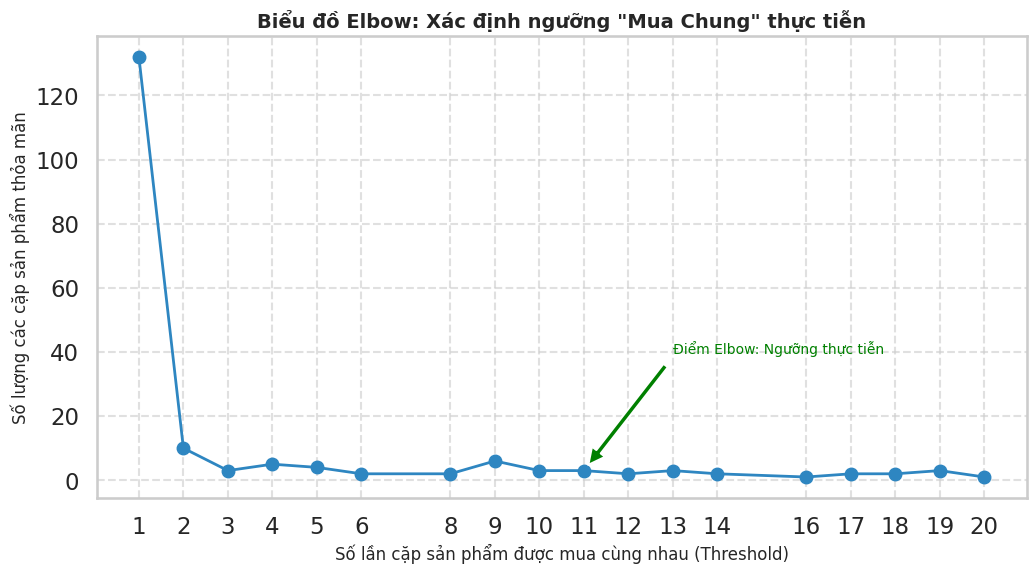

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# --- BƯỚC 0: TÁI LẬP BIẾN 'pair_counts' ---
# Giả định bạn đã có DataFrame 'basket_prep' (chứa order_id và category) từ các bước trước
# Chúng ta thực hiện self-join để tìm các cặp sản phẩm mua cùng nhau
pairs = pd.merge(basket_prep, basket_prep, on=['order_id', 'category'])

# Chỉ giữ lại các cặp sản phẩm khác nhau và tránh lặp hoán vị (A-B và B-A)
pairs = pairs[pairs['product_name_x'] < pairs['product_name_y']]

# Đếm tần suất xuất hiện của mỗi cặp
pair_counts = pairs.groupby(['category', 'product_name_x', 'product_name_y']).size().reset_index(name='Count_Mua_Chung')

# --- BƯỚC 1: TẠO BIẾN 'dist' ---
dist = pair_counts.groupby('Count_Mua_Chung').size().reset_index(name='Số_Lượng_Cặp')

# --- BƯỚC 2: VẼ BIỂU ĐỒ ELBOW ---
plot_data = dist[dist['Count_Mua_Chung'] <= 20]

plt.figure(figsize=(12, 6))
plt.plot(plot_data['Count_Mua_Chung'], plot_data['Số_Lượng_Cặp'],
         marker='o', linestyle='-', color='#2E86C1', linewidth=2, label='Số lượng cặp')

plt.title('Biểu đồ Elbow: Xác định ngưỡng "Mua Chung" thực tiễn', fontsize=14, fontweight='bold')
plt.xlabel('Số lần cặp sản phẩm được mua cùng nhau (Threshold)', fontsize=12)
plt.ylabel('Số lượng các cặp sản phẩm thỏa mãn', fontsize=12)

# Chú thích điểm Elbow tại ngưỡng 11
if 11 in plot_data['Count_Mua_Chung'].values:
    y_val = plot_data[plot_data['Count_Mua_Chung']==11]['Số_Lượng_Cặp'].values[0]
    plt.annotate('Điểm Elbow: Ngưỡng thực tiễn', xy=(11, y_val),
                 xytext=(13, plot_data['Số_Lượng_Cặp'].max()*0.3),
                 arrowprops=dict(facecolor='green', shrink=0.05), fontsize=10, color='green')

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(plot_data['Count_Mua_Chung'])
plt.show()

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("🚀 ĐANG KHỞI ĐỘNG HỆ THỐNG PHÂN TÍCH GIỎ HÀNG TOÀN DIỆN...")

# ==============================================================================
# BƯỚC 1: NẠP VÀ TIỀN XỬ LÝ DỮ LIỆU (DATA PREPARATION)
# ==============================================================================
print("⏳ Đang nạp và hợp nhất dữ liệu từ các file CSV...")
orders = df_orders.copy()
order_items = df_order_items.copy()
products = df_products.copy()

# 1.1 Tạo nhãn Khách Mới / Khách Cũ
user_stats = orders.groupby('customer_id')['order_id'].nunique().reset_index(name='total_orders')
user_stats['customer_type'] = np.where(user_stats['total_orders'] == 1, 'Khách Mới', 'Khách Cũ')

# 1.2 Hợp nhất thành bảng 'basket_prep' chứa đầy đủ thông tin
basket_prep = pd.merge(order_items, products[['product_id', 'product_name', 'category']], on='product_id')
basket_prep = pd.merge(basket_prep, orders[['order_id', 'customer_id']], on='order_id')
basket_prep = pd.merge(basket_prep, user_stats[['customer_id', 'customer_type']], on='customer_id')

# ==============================================================================
# BƯỚC 2: TÍNH LIFT SCORE TOÀN SÀN & LỌC OUTDOOR
# ==============================================================================
print("⏳ Đang tính toán Hệ số Nâng (Lift Score) cho tất cả danh mục...")

# 2.1 Tính thông số cơ sở
cat_totals = basket_prep.groupby('category')['order_id'].nunique().reset_index(name='Total_Orders_Cat')
item_counts = basket_prep.groupby(['category', 'product_name'])['order_id'].nunique().reset_index(name='Count_Đơn_Lẻ')

# 2.2 Tự kết nối (Self-join) để tìm cặp mua chung
pairs = pd.merge(basket_prep[['order_id', 'category', 'product_name']],
                 basket_prep[['order_id', 'category', 'product_name']],
                 on=['order_id', 'category'])
pairs = pairs[pairs['product_name_x'] < pairs['product_name_y']] # Khử hoán vị (A-B và B-A)

# Đếm tần suất mua chung
pair_counts = pairs.groupby(['category', 'product_name_x', 'product_name_y']).size().reset_index(name='Count_Mua_Chung')
pair_counts_filtered = pair_counts[pair_counts['Count_Mua_Chung'] >= 3] # Bỏ nhiễu nhẹ >= 3 để tính Lift

# 2.3 Tính Lift Score
rules = pd.merge(pair_counts_filtered, item_counts, left_on=['category', 'product_name_x'], right_on=['category', 'product_name'])
rules.rename(columns={'Count_Đơn_Lẻ': 'Count_A'}, inplace=True)
rules.drop(columns=['product_name'], inplace=True)

rules = pd.merge(rules, item_counts, left_on=['category', 'product_name_y'], right_on=['category', 'product_name'])
rules.rename(columns={'Count_Đơn_Lẻ': 'Count_B'}, inplace=True)
rules.drop(columns=['product_name'], inplace=True)

rules = pd.merge(rules, cat_totals, on='category')
rules['Lift_Score'] = (rules['Count_Mua_Chung'] * rules['Total_Orders_Cat']) / (rules['Count_A'] * rules['Count_B'])

# Đổi tên cho đẹp
rules = rules.rename(columns={'product_name_x': 'Sản Phẩm A', 'product_name_y': 'Sản Phẩm B'})

# ==============================================================================
# 2.4 VÒNG LẶP TỰ ĐỘNG: QUÉT TOP 3 COMBO CHO TẤT CẢ DANH MỤC (ALL CATEGORIES)
# ==============================================================================
print("\n" + "="*80)
print("🌍 BÁO CÁO TỰ ĐỘNG: TOP 3 CẶP BÀI TRÙNG ĐỈNH NHẤT TỪNG DANH MỤC")
print("="*80)

# Lấy danh sách tất cả các Danh mục (Category) đang có trong siêu thị
all_categories = rules['category'].dropna().unique()

# Vòng lặp duyệt qua từng danh mục một
for cat in all_categories:
    # 1. Lọc bảng Lift Score riêng cho danh mục đó
    cat_rules = rules[rules['category'] == cat].copy()

    # 2. Lọc độ nhiễu (chỉ lấy cặp có >= 3 lần mua chung) và Sắp xếp Lift_Score giảm dần
    top_3_combo = cat_rules[cat_rules['Count_Mua_Chung'] >= 3].sort_values('Lift_Score', ascending=False).head(3)

    # 3. In kết quả với Tiêu đề tự động thay đổi theo tên Category
    print(f"\n🏷️ DANH MỤC: {cat.upper()}")
    print("-" * 65)

    # Nếu có dữ liệu thì in bảng, nếu danh mục đó ế quá thì báo không có
    if not top_3_combo.empty:
        print(top_3_combo[['Sản Phẩm A', 'Sản Phẩm B', 'Count_Mua_Chung', 'Lift_Score']].round(2).to_string(index=False))
    else:
        print("  ❌ Chưa có Combo nào đạt chuẩn (>= 3 lần mua chung) để phân tích.")

# ==============================================================================
# BƯỚC 3: PHÂN TÍCH VI SAI (DIFFERENTIAL ANALYSIS: KHÁCH MỚI VS KHÁCH CŨ)
# ==============================================================================
print("\n⏳ Đang chạy Phân tích Vi sai (Khách Mới vs Khách Cũ)...")

def calculate_lift_for_segment(df_segment):
    total_orders = df_segment['order_id'].nunique()
    if total_orders == 0:
        return pd.DataFrame(columns=['product_name_x', 'product_name_y', 'Count_Mua_Chung', 'Lift'])

    i_counts = df_segment.groupby('product_name')['order_id'].nunique().reset_index(name='Count_Don_Le')

    prs = pd.merge(df_segment[['order_id', 'product_name']], df_segment[['order_id', 'product_name']], on='order_id')
    prs = prs[prs['product_name_x'] < prs['product_name_y']]
    p_counts = prs.groupby(['product_name_x', 'product_name_y']).size().reset_index(name='Count_Mua_Chung')
    p_counts = p_counts[p_counts['Count_Mua_Chung'] >= 10] # Lọc >= 10 cho từng phân khúc

    if p_counts.empty:
        return pd.DataFrame(columns=['product_name_x', 'product_name_y', 'Count_Mua_Chung', 'Lift'])

    # --- FIX LỖI Ở ĐÂY: XÓA CỘT THỪA SAU KHI MERGE ---
    # Merge lần 1 (Lấy Count A)
    seg_rules = pd.merge(p_counts, i_counts, left_on='product_name_x', right_on='product_name')
    seg_rules.rename(columns={'Count_Don_Le': 'Count_A'}, inplace=True)
    seg_rules.drop(columns=['product_name'], inplace=True) # Xóa cột rác

    # Merge lần 2 (Lấy Count B)
    seg_rules = pd.merge(seg_rules, i_counts, left_on='product_name_y', right_on='product_name')
    seg_rules.rename(columns={'Count_Don_Le': 'Count_B'}, inplace=True)
    seg_rules.drop(columns=['product_name'], inplace=True) # Xóa cột rác
    # -------------------------------------------------

    seg_rules['Lift'] = (seg_rules['Count_Mua_Chung'] * total_orders) / (seg_rules['Count_A'] * seg_rules['Count_B'])
    return seg_rules[['product_name_x', 'product_name_y', 'Lift']]

# Tính Lift cho 2 nhóm
rules_new = calculate_lift_for_segment(basket_prep[basket_prep['customer_type'] == 'Khách Mới'])
rules_old = calculate_lift_for_segment(basket_prep[basket_prep['customer_type'] == 'Khách Cũ'])

# Tính Delta Lift (Vi sai)
diff_rules = pd.merge(rules_new, rules_old, on=['product_name_x', 'product_name_y'], how='outer', suffixes=('_Mới', '_Cũ')).fillna(0)
diff_rules['Delta_Lift'] = diff_rules['Lift_Mới'] - diff_rules['Lift_Cũ']
diff_rules = diff_rules.rename(columns={'product_name_x': 'Sản Phẩm A', 'product_name_y': 'Sản Phẩm B'})

print("\n" + "="*80)
print("🎯 TOP 3 COMBO BẮT KHÁCH MỚI (CHẠY ADS):")
print("="*80)
# Sắp xếp Delta_Lift giảm dần để lấy giá trị Dương cao nhất
print(diff_rules.sort_values('Delta_Lift', ascending=False).head(3).round(2).to_string(index=False))

print("\n" + "="*80)
print("💎 TOP 3 COMBO GIỮ CHÂN KHÁCH CŨ (GỬI EMAIL/ZALO):")
print("="*80)
# Sắp xếp Delta_Lift tăng dần để lấy giá trị Âm sâu nhất (Khách cũ lực hút mạnh nhất)
print(diff_rules.sort_values('Delta_Lift', ascending=True).head(3).round(2).to_string(index=False))

🚀 ĐANG KHỞI ĐỘNG HỆ THỐNG PHÂN TÍCH GIỎ HÀNG TOÀN DIỆN...
⏳ Đang nạp và hợp nhất dữ liệu từ các file CSV...
⏳ Đang tính toán Hệ số Nâng (Lift Score) cho tất cả danh mục...

🌍 BÁO CÁO TỰ ĐỘNG: TOP 3 CẶP BÀI TRÙNG ĐỈNH NHẤT TỪNG DANH MỤC

🏷️ DANH MỤC: CASUAL
-----------------------------------------------------------------
    Sản Phẩm A     Sản Phẩm B  Count_Mua_Chung  Lift_Score
VietMode MP-17 VietMode MP-18                3     2360.00
VietMode MP-07 VietMode MP-08                7     1501.82
VietMode MP-03 VietMode MP-04                5      561.90

🏷️ DANH MỤC: GENZ
-----------------------------------------------------------------
       Sản Phẩm A        Sản Phẩm B  Count_Mua_Chung  Lift_Score
 VietMotion YY-05  VietMotion YY-09                9        0.07
 VietMotion YY-05  VietMotion YY-21                6        0.05
HanoiStreet YY-01 HanoiStreet YY-10                3        0.01

🏷️ DANH MỤC: OUTDOOR
-----------------------------------------------------------------
       S

In [26]:
import pandas as pd
import numpy as np

print("🚀 ĐANG CHẠY ALL-IN-ONE SCRIPT: ĐỒNG BỘ DOANH THU & TÍNH TOÁN...")

# ==============================================================================
# KHÂU 1: TẠO CỘT DOANH THU (TOTAL_AMOUNT) TỪ BẢNG PRODUCTS & ORDER_ITEMS
# ==============================================================================
# ⚠️ HÃY ĐIỀN TÊN CỘT CHỨA GIÁ TRONG BẢNG df_products VÀO ĐÂY:
TEN_COT_GIA = 'price'

# Kéo giá từ products sang order_items (chỉ lấy đúng 2 cột để không bị rác)
items_with_price = pd.merge(df_order_items,
                            df_products[['product_id', TEN_COT_GIA]],
                            on='product_id',
                            how='left')

# Tính tiền từng dòng (Nếu data của bạn có cột số lượng 'quantity', hãy sửa thành: items_with_price[TEN_COT_GIA] * items_with_price['quantity'])
items_with_price['line_total'] = items_with_price[TEN_COT_GIA]* items_with_price['quantity']

# Gom nhóm theo hóa đơn -> TẠO RA CỘT TOTAL_AMOUNT
order_billing = items_with_price.groupby('order_id')['line_total'].sum().reset_index(name='total_amount')

# Gắn cột total_amount vừa tạo vào bảng orders gốc -> TẠO RA BẢNG DF CHUẨN
df = pd.merge(df_orders, order_billing, on='order_id', how='left')


# ==============================================================================
# KHÂU 2: TIỀN XỬ LÝ VÀ CHIA KHUNG THỜI GIAN THEO THÁNG
# ==============================================================================
# Lọc đơn thành công
df = df[df['order_status'].str.lower().isin(['completed', 'delivered'])].copy()
df['order_date'] = pd.to_datetime(df['order_date'])
# Tìm ngày giao dịch gần nhất trong tập dữ liệu (Làm mốc hiện tại)
latest_date = df['order_date'].max()

# Lùi lại đúng 5 năm (5 * 365 ngày)
start_date = latest_date - pd.DateOffset(years=4)

# Chặt bỏ toàn bộ dữ liệu trước start_date
df = df[df['order_date'] >= start_date].copy()
# Tạo cột Tháng-Năm để gom nhóm
df['month_year'] = df['order_date'].dt.to_period('M')


# ==============================================================================
# KHÂU 3: TÍNH CÁC CHỈ SỐ DỰ BÁO
# ==============================================================================
# Tốc độ thu hút Khách Mới
first_orders = df.groupby('customer_id')['order_date'].min().reset_index()
first_orders['first_month'] = first_orders['order_date'].dt.to_period('M')
monthly_acquisition = first_orders.groupby('first_month').size().reset_index(name='New_Customers')

# CÁC CHỈ SỐ CƠ BẢN (Lúc này df CHẮC CHẮN ĐÃ CÓ total_amount, không thể lỗi KeyError)
monthly_stats = df.groupby('month_year').agg(
    Total_Orders=('order_id', 'nunique'),
    Total_Revenue=('total_amount', 'sum'),
    Active_Customers=('customer_id', 'nunique')
).reset_index()

# Ráp số liệu lại với nhau
monthly_report = pd.merge(monthly_stats, monthly_acquisition, left_on='month_year', right_on='first_month', how='left')
monthly_report['New_Customers'] = monthly_report['New_Customers'].fillna(0)

# Tính toán các chỉ số phái sinh
monthly_report['Retained_Customers'] = monthly_report['Active_Customers'] - monthly_report['New_Customers']
monthly_report['Purchase_Frequency'] = monthly_report['Total_Orders'] / monthly_report['Active_Customers']
monthly_report['AOV'] = monthly_report['Total_Revenue'] / monthly_report['Total_Orders']


# ==============================================================================
# KHÂU 4: KIỂM ĐỊNH TÍNH ỔN ĐỊNH BẰNG CV (COEFFICIENT OF VARIATION)
# ==============================================================================
print("\n📊 BÁO CÁO TÍNH ỔN ĐỊNH CỦA CÁC CHỈ SỐ DỰ BÁO (HÀNG THÁNG)")
print("-" * 85)

metrics = {
    'Khách Mới/Tháng (Acquisition)': 'New_Customers',
    'Khách Cũ Mua Lại/Tháng (Retention)': 'Retained_Customers',
    'Giá trị Đơn hàng (AOV)': 'AOV',
    'Tần suất Mua (Orders/Customer)': 'Purchase_Frequency'
}

stability_results = []

for label, col in metrics.items():
    ewma_series = monthly_report[col].ewm(span=12, adjust=False).mean()

    # Lấy giá trị EWMA của tháng cuối cùng làm con số đại diện để đem đi dự báo
    mean_val = ewma_series.iloc[-1]
    std_val = monthly_report[col].std()
    cv_pct = (std_val / mean_val) * 100 if mean_val > 0 else 0

    if cv_pct <= 15:
        status = "🟢 Rất Ổn định (An toàn dự báo)"
    elif cv_pct <= 30:
        status = "🟡 Có tính mùa vụ"
    else:
        status = "🔴 Biến động mạnh (Khó dự báo tĩnh)"

    stability_results.append({
        'Chỉ số (Metrics)': label,
        'Trung bình (Mean)': round(mean_val, 2),
        'Độ lệch chuẩn (STD)': round(std_val, 2),
        'Độ biến thiên (CV %)': round(cv_pct, 2),
        'Đánh giá': status
    })

df_stability = pd.DataFrame(stability_results)
print(df_stability.to_string(index=False))

🚀 ĐANG CHẠY ALL-IN-ONE SCRIPT: ĐỒNG BỘ DOANH THU & TÍNH TOÁN...

📊 BÁO CÁO TÍNH ỔN ĐỊNH CỦA CÁC CHỈ SỐ DỰ BÁO (HÀNG THÁNG)
-------------------------------------------------------------------------------------
                  Chỉ số (Metrics)  Trung bình (Mean)  Độ lệch chuẩn (STD)  Độ biến thiên (CV %)                           Đánh giá
     Khách Mới/Tháng (Acquisition)             474.02               719.76                151.84 🔴 Biến động mạnh (Khó dự báo tĩnh)
Khách Cũ Mua Lại/Tháng (Retention)            1553.15               609.47                 39.24 🔴 Biến động mạnh (Khó dự báo tĩnh)
            Giá trị Đơn hàng (AOV)           33333.83              3022.57                  9.07     🟢 Rất Ổn định (An toàn dự báo)
    Tần suất Mua (Orders/Customer)               1.04                 0.01                  1.07     🟢 Rất Ổn định (An toàn dự báo)


🎨 ĐANG VẼ BIỂU ĐỒ PHÂN TÍCH LƯỢNG KHÁCH 5 NĂM GẦN NHẤT...


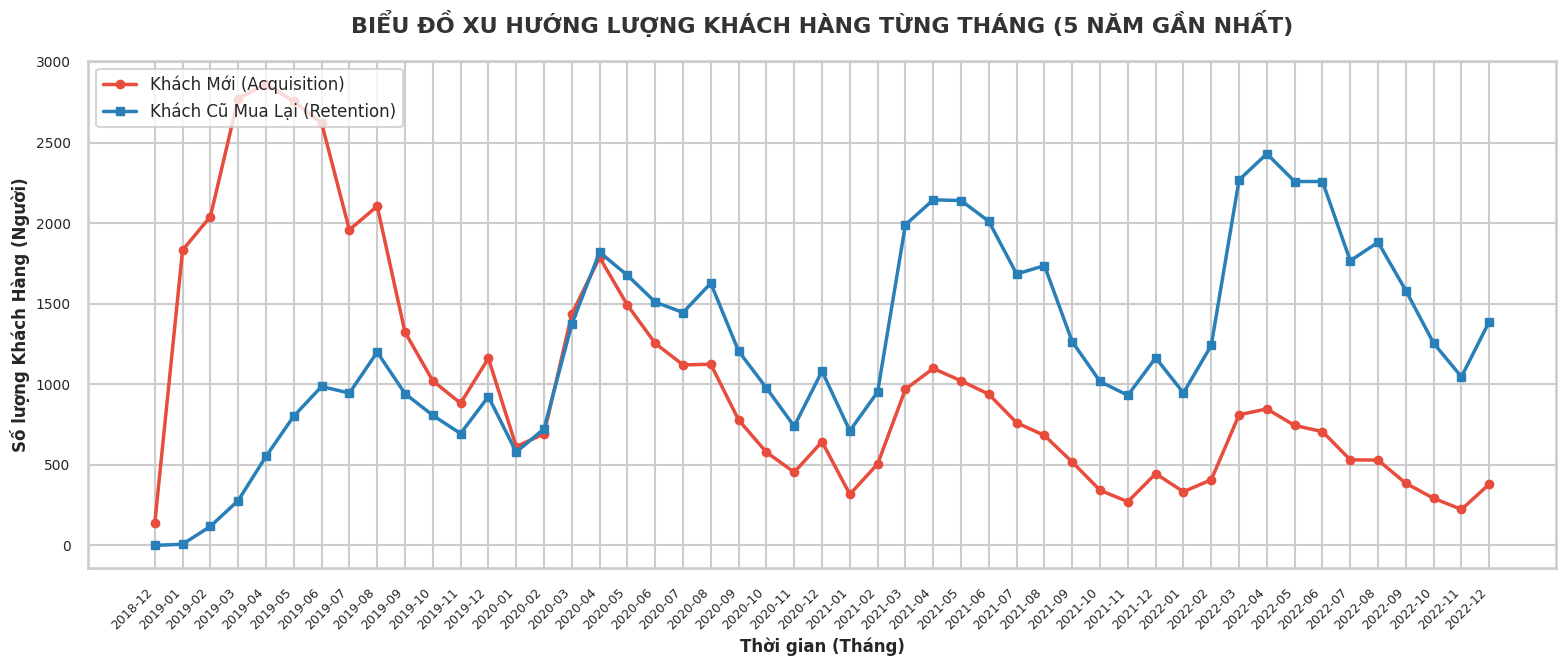

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

print("🎨 ĐANG VẼ BIỂU ĐỒ PHÂN TÍCH LƯỢNG KHÁCH 5 NĂM GẦN NHẤT...")

# 1. Lấy dữ liệu của 60 tháng (5 năm) gần nhất từ bảng monthly_report đã có
plot_data = monthly_report.tail(60).copy()

# Ép kiểu cột Tháng-Năm sang dạng chuỗi (String) để trục X hiển thị đẹp hơn
plot_data['Month_Str'] = plot_data['month_year'].astype(str)

# 2. Thiết lập kích thước và phong cách biểu đồ
plt.figure(figsize=(16, 7))
sns.set_style("whitegrid")

# 3. Vẽ đường Khách Mới (Màu đỏ - tượng trưng cho sự báo động/chi phí)
plt.plot(plot_data['Month_Str'], plot_data['New_Customers'],
         marker='o', markersize=6, linewidth=2.5,
         color='#e74c3c', label='Khách Mới (Acquisition)')

# 4. Vẽ đường Khách Cũ Mua Lại (Màu xanh dương - tượng trưng cho sự ổn định)
plt.plot(plot_data['Month_Str'], plot_data['Retained_Customers'],
         marker='s', markersize=6, linewidth=2.5,
         color='#2980b9', label='Khách Cũ Mua Lại (Retention)')

# 5. Trang trí tiêu đề và các trục
plt.title('BIỂU ĐỒ XU HƯỚNG LƯỢNG KHÁCH HÀNG TỪNG THÁNG (5 NĂM GẦN NHẤT)',
          fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Thời gian (Tháng)', fontsize=12, fontweight='bold')
plt.ylabel('Số lượng Khách Hàng (Người)', fontsize=12, fontweight='bold')

# Xoay nhãn trục X một góc 45 độ để chữ không bị đè lên nhau
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=10)

# 6. Thêm chú thích và căn lề
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

# 7. Hiển thị kết quả
plt.show()

In [35]:
print("📉 ĐANG TÍNH TOÁN CHURN RATE THỰC TẾ THEO TỪNG THÁNG...")

# 1. Lấy danh sách khách hàng của từng tháng (Sử dụng bảng df_success đã lọc đơn thành công)
monthly_customers = df_success.groupby('month_year')['customer_id'].apply(set).reset_index()

# 2. Tính toán tỷ lệ quay lại và rời bỏ giữa 2 tháng liên tiếp
churn_results = []

for i in range(len(monthly_customers) - 1):
    current_month = monthly_customers.iloc[i]['month_year']
    next_month = monthly_customers.iloc[i+1]['month_year']

    set_current = monthly_customers.iloc[i]['customer_id']
    set_next = monthly_customers.iloc[i+1]['customer_id']

    # Khách quay lại = Những người có mặt ở cả tháng này và tháng sau
    retained_customers = set_current.intersection(set_next)

    # Tỷ lệ giữ chân (Retention Rate)
    retention_rate = len(retained_customers) / len(set_current) if len(set_current) > 0 else 0

    # Tỷ lệ rời bỏ (Churn Rate) = 1 - Retention Rate
    actual_churn_rate = 1 - retention_rate

    churn_results.append({
        'Tháng': str(current_month),
        'Số khách tháng này': len(set_current),
        'Khách quay lại tháng sau': len(retained_customers),
        'Actual_Churn_Rate (%)': round(actual_churn_rate * 100, 2)
    })

df_actual_churn = pd.DataFrame(churn_results)

# 3. Tính Churn Rate trung bình thực tế để đưa vào công thức CLV
mean_actual_churn = df_actual_churn['Actual_Churn_Rate (%)'].mean() / 100

print(df_actual_churn.to_string(index=False))
print(f"\n✅ KẾT QUẢ: Churn Rate thực tế trung bình của công ty là: {mean_actual_churn:.2%}")
if mean_actual_churn > 0.7:
    print("⚠️ CẢNH BÁO: Churn Rate thực tế còn cao hơn cả mức giả định 70%!")
else:
    print("✨ TIN TỐT: Khách hàng của bạn trung thành hơn mức chúng ta tưởng.")

📉 ĐANG TÍNH TOÁN CHURN RATE THỰC TẾ THEO TỪNG THÁNG...
  Tháng  Số khách tháng này  Khách quay lại tháng sau  Actual_Churn_Rate (%)
2017-12                 233                        19                  91.85
2018-01                2433                       210                  91.37
2018-02                2947                       344                  88.33
2018-03                4733                       633                  86.63
2018-04                6005                       961                  84.00
2018-05                7182                      1222                  82.99
2018-06                7858                       913                  88.38
2018-07                5481                       621                  88.67
2018-08                4909                       394                  91.97
2018-09                3171                       204                  93.57
2018-10                2460                       128                  94.80
2018-11              

In [38]:
import pandas as pd
import numpy as np

print("🚀 ĐANG KHỞI ĐỘNG HỆ THỐNG PHÂN TÍCH CHUYÊN SÂU 4 CHỈ SỐ VÒNG ĐỜI (5 NĂM GẦN NHẤT)...")

# ==============================================================================
# BƯỚC 1 (ĐÃ SỬA LỖI): TẠO BẢNG GỐC VÀ LỌC DỮ LIỆU 5 NĂM
# ==============================================================================
# 1.1 Tái tạo lại bảng doanh thu chứa TOÀN BỘ TRẠNG THÁI (để tính được số đơn hủy)
TEN_COT_GIA = 'price' # Nhớ sửa tên cột này cho khớp với df_products của bạn
items_tmp = pd.merge(df_order_items, df_products[['product_id', TEN_COT_GIA]], on='product_id', how='left')

# Đã thêm phần nhân quantity như bạn đã phát hiện ở lỗi AOV trước đó
items_tmp['line_total'] = items_tmp[TEN_COT_GIA] * items_tmp['quantity']
order_billing = items_tmp.groupby('order_id')['line_total'].sum().reset_index(name='total_amount')

# 1.2 Tạo bảng df_all chứa tất cả các đơn
df_all = pd.merge(df_orders, order_billing, on='order_id', how='left')
df_all['order_date'] = pd.to_datetime(df_all['order_date'])

# 1.3 Bộ lọc 5 năm gần nhất
latest_date = df_all['order_date'].max()
start_date = latest_date - pd.DateOffset(years=5)
df_5y = df_all[df_all['order_date'] >= start_date].copy()

# Thêm cột Tháng-Năm để thống kê
df_5y['month_year'] = df_5y['order_date'].dt.to_period('M')

# ==============================================================================
# BƯỚC 2: TÍNH TOÁN 4 CHỈ SỐ CHO TỪNG THÁNG
# ==============================================================================

monthly_metrics = []
months = df_5y['month_year'].unique()

# Tính Time Between Purchases (TBP) toàn cục trước để dễ lấy theo tháng
# Chỉ lấy các đơn thành công để tính TBP
df_success = df_5y[df_5y['order_status'].str.lower().isin(['completed', 'delivered'])].copy()
df_success = df_success.sort_values(['customer_id', 'order_date'])
df_success['prev_order_date'] = df_success.groupby('customer_id')['order_date'].shift(1)
df_success['days_between'] = (df_success['order_date'] - df_success['prev_order_date']).dt.days

for month in sorted(months):
    # Dữ liệu của tháng đang xét
    df_month = df_5y[df_5y['month_year'] == month]
    df_month_success = df_success[df_success['month_year'] == month]

    # -----------------------------------------------------------
    # 1. Tỷ lệ Hoàn/Hủy (Cancellation Rate)
    # -----------------------------------------------------------
    total_orders = len(df_month)
    cancelled_orders = len(df_month[df_month['order_status'].str.lower().isin(['cancelled', 'refunded', 'failed'])])
    cancel_rate = (cancelled_orders / total_orders) * 100 if total_orders > 0 else 0

    # -----------------------------------------------------------
    # 2. Net Revenue (Doanh thu ròng = Bán được - Bị hoàn hủy)
    # -----------------------------------------------------------
    gross_revenue = df_month['total_amount'].sum()
    refunded_revenue = df_month[df_month['order_status'].str.lower().isin(['cancelled', 'refunded', 'failed'])]['total_amount'].sum()
    net_revenue = gross_revenue - refunded_revenue

    # -----------------------------------------------------------
    # 3. Time Between Purchases (TBP) trung bình của tháng
    # -----------------------------------------------------------
    # Lấy những khách hàng có mua lần 2, lần 3... trong tháng này
    tbp_month = df_month_success['days_between'].dropna()
    avg_tbp = tbp_month.mean() if not tbp_month.empty else 0

    # -----------------------------------------------------------
    # 4. Customer Lifetime Value (CLV)
    # -----------------------------------------------------------
    # Cách tính CLV thực chiến: Lợi nhuận ròng / Số lượng khách mua trong tháng
    active_customers = df_month_success['customer_id'].nunique()
    arpu = (net_revenue / active_customers) if active_customers > 0 else 0

    # Áp dụng True Churn Rate đã tính được
    churn_rate = 0.6794
    clv = arpu / churn_rate

    # Lưu lại
    monthly_metrics.append({
        'Tháng': str(month),
        'Cancel_Rate (%)': cancel_rate,
        'Net_Revenue (VNĐ)': net_revenue,
        'TBP (Ngày)': avg_tbp,
        'CLV (VNĐ)': clv
    })

df_metrics = pd.DataFrame(monthly_metrics)

# ==============================================================================
# BƯỚC 3: ĐÁNH GIÁ ĐỘ ỔN ĐỊNH VÀ IN BÁO CÁO (MEAN, STD, CV)
# ==============================================================================
print("\n📊 BÁO CÁO 4 CHỈ SỐ CHIẾN LƯỢC (5 NĂM GẦN NHẤT)")
print("-" * 90)

indicators = {
    '1. Tỷ lệ Hoàn/Hủy (%)': 'Cancel_Rate (%)',
    '2. Doanh thu Ròng (VNĐ)': 'Net_Revenue (VNĐ)',
    '3. Thời gian mua lại - TBP (Ngày)': 'TBP (Ngày)',
    '4. Giá trị Vòng đời - CLV (VNĐ)': 'CLV (VNĐ)'
}

results = []

for label, col in indicators.items():
    # Bỏ qua các tháng có giá trị 0 (ví dụ tháng đó không có khách cũ mua lại)
    valid_data = df_metrics[df_metrics[col] > 0][col]

    mean_val = valid_data.mean() if not valid_data.empty else 0
    std_val = valid_data.std() if not valid_data.empty else 0
    cv_pct = (std_val / mean_val) * 100 if mean_val > 0 else 0

    if cv_pct <= 15:
        status = "🟢 Ổn định"
    elif cv_pct <= 30:
        status = "🟡 Cảnh báo nhẹ"
    else:
        status = "🔴 Rủi ro cao"

    results.append({
        'Chỉ số Chiến lược': label,
        'Trung bình (Mean)': round(mean_val, 2),
        'Độ lệch chuẩn (STD)': round(std_val, 2),
        'Hệ số CV (%)': round(cv_pct, 2),
        'Đánh giá': status
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

🚀 ĐANG KHỞI ĐỘNG HỆ THỐNG PHÂN TÍCH CHUYÊN SÂU 4 CHỈ SỐ VÒNG ĐỜI (5 NĂM GẦN NHẤT)...

📊 BÁO CÁO 4 CHỈ SỐ CHIẾN LƯỢC (5 NĂM GẦN NHẤT)
------------------------------------------------------------------------------------------
                Chỉ số Chiến lược  Trung bình (Mean)  Độ lệch chuẩn (STD)  Hệ số CV (%)     Đánh giá
            1. Tỷ lệ Hoàn/Hủy (%)               9.28                 0.47          5.09    🟢 Ổn định
          2. Doanh thu Ròng (VNĐ)        99905149.67          47769047.13         47.81 🔴 Rủi ro cao
3. Thời gian mua lại - TBP (Ngày)             308.03               156.37         50.77 🔴 Rủi ro cao
  4. Giá trị Vòng đời - CLV (VNĐ)           55904.24              6499.90         11.63    🟢 Ổn định


In [36]:
print("🔍 ĐANG PHÂN TÍCH CHURN RATE DỰA TRÊN NHỊP ĐỘ MUA SẮM THỰC TẾ (5 NĂM)...")

# ==============================================================================
# BƯỚC 1: TÍNH TBP (MEAN & MEDIAN) TOÀN CỤC TRONG 5 NĂM
# ==============================================================================
# Lọc các đơn thành công và tính khoảng cách ngày mua
df_success = df_5y[df_5y['order_status'].str.lower().isin(['completed', 'delivered'])].copy()
df_success = df_success.sort_values(['customer_id', 'order_date'])
df_success['prev_order_date'] = df_success.groupby('customer_id')['order_date'].shift(1)
df_success['days_between'] = (df_success['order_date'] - df_success['prev_order_date']).dt.days

# Lấy các khoảng thời gian hợp lệ (loại bỏ giá trị NaN của đơn hàng đầu tiên)
valid_tbp = df_success['days_between'].dropna()

tbp_mean = valid_tbp.mean()
tbp_median = valid_tbp.median()
tbp_std = valid_tbp.std()

print(f"📊 KẾT QUẢ ĐO LƯỜNG NHỊP ĐỘ MUA SẮM (TBP):")
print(f"- Khoảng thời gian mua lại Trung bình (Mean): {tbp_mean:.1f} ngày")
print(f"- Khoảng thời gian mua lại Phổ biến nhất (Median): {tbp_median:.1f} ngày")
print(f"- Độ lệch chuẩn (STD): {tbp_std:.1f} ngày")

# ==============================================================================
# BƯỚC 2: ĐỊNH NGHĨA "CỬA SỔ CHURN" (CHURN WINDOW)
# ==============================================================================
# Trong E-commerce, dùng Mean thường an toàn hơn Median vì nó bao hàm được các khách hàng mua chậm.
# Bạn cũng có thể cộng thêm một khoảng đệm (Ví dụ: Mean + 30 ngày) để chắc chắn họ không quay lại.
CHURN_WINDOW_DAYS = int(tbp_mean)

print(f"\n⚙️ Đang thiết lập Cửa sổ Churn (Ngưỡng rời bỏ) = {CHURN_WINDOW_DAYS} ngày.")

# ==============================================================================
# BƯỚC 3: TÍNH TRUE CHURN RATE TẠI THỜI ĐIỂM HIỆN TẠI
# ==============================================================================
# Lấy ngày giao dịch cuối cùng của toàn bộ hệ thống (Được coi là ngày "Hôm nay" trong data)
current_date = df_success['order_date'].max()

# Lấy ngày mua hàng MỚI NHẤT của TỪNG KHÁCH HÀNG
customer_last_purchase = df_success.groupby('customer_id')['order_date'].max().reset_index()
customer_last_purchase.columns = ['customer_id', 'last_order_date']

# Tính xem đã bao nhiêu ngày trôi qua kể từ lần cuối họ mua hàng
customer_last_purchase['days_since_last_order'] = (current_date - customer_last_purchase['last_order_date']).dt.days

# Phân loại: Nếu số ngày vắng mặt > Ngưỡng Churn Window -> Khách đã Churn
customer_last_purchase['is_churned'] = customer_last_purchase['days_since_last_order'] > CHURN_WINDOW_DAYS

# Tính Tỷ lệ
total_customers = len(customer_last_purchase)
churned_customers = customer_last_purchase['is_churned'].sum()
true_churn_rate = churned_customers / total_customers

print("\n🚩 BÁO CÁO TỶ LỆ RỜI BỎ THỰC TẾ (TRUE CHURN RATE):")
print("-" * 60)
print(f"Tổng số khách hàng trong 5 năm: {total_customers:,.0f} người")
print(f"Số khách hàng đã chính thức Rời bỏ (vắng mặt > {CHURN_WINDOW_DAYS} ngày): {churned_customers:,.0f} người")
print(f"Số khách hàng vẫn đang Active: {total_customers - churned_customers:,.0f} người")
print("-" * 60)
print(f"➡️ TRUE CHURN RATE: {true_churn_rate:.2%}")

🔍 ĐANG PHÂN TÍCH CHURN RATE DỰA TRÊN NHỊP ĐỘ MUA SẮM THỰC TẾ (5 NĂM)...
📊 KẾT QUẢ ĐO LƯỜNG NHỊP ĐỘ MUA SẮM (TBP):
- Khoảng thời gian mua lại Trung bình (Mean): 308.8 ngày
- Khoảng thời gian mua lại Phổ biến nhất (Median): 194.0 ngày
- Độ lệch chuẩn (STD): 328.1 ngày

⚙️ Đang thiết lập Cửa sổ Churn (Ngưỡng rời bỏ) = 308 ngày.

🚩 BÁO CÁO TỶ LỆ RỜI BỎ THỰC TẾ (TRUE CHURN RATE):
------------------------------------------------------------
Tổng số khách hàng trong 5 năm: 59,094 người
Số khách hàng đã chính thức Rời bỏ (vắng mặt > 308 ngày): 40,146 người
Số khách hàng vẫn đang Active: 18,948 người
------------------------------------------------------------
➡️ TRUE CHURN RATE: 67.94%


In [32]:
import pandas as pd

print("🎯 ĐANG TÍNH TOÁN CAC DỰA TRÊN CHI PHÍ TRỢ GIÁ (PROMO-CAC)...")

# ==============================================================================
# BƯỚC 1: TÌM "ĐƠN HÀNG KHAI SINH" CỦA TỪNG KHÁCH
# ==============================================================================
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# Tìm ngày mua đầu tiên của mỗi khách hàng
first_orders = df_orders.loc[df_orders.groupby('customer_id')['order_date'].idxmin()].copy()

# Lấy danh sách các mã đơn hàng (order_id) đầu tiên này
first_order_ids = first_orders['order_id'].unique()

# ==============================================================================
# BƯỚC 2: TÍNH TIỀN "ĐỐT" VÀO PROMO CHO CÁC ĐƠN KHAI SINH
# ==============================================================================
# Lọc bảng chi tiết chỉ lấy các món hàng thuộc về đơn đầu tiên
first_order_items = df_order_items[df_order_items['order_id'].isin(first_order_ids)].copy()

# Điền 0 cho những dòng không có giảm giá (để tránh lỗi khi tính tổng)
first_order_items['discount_amount'] = first_order_items['discount_amount'].fillna(0)

# Gom nhóm theo order_id để xem mỗi ĐƠN ĐẦU TIÊN được công ty bao trọn bao nhiêu tiền Khuyến mãi
cac_per_order = first_order_items.groupby('order_id')['discount_amount'].sum().reset_index()
cac_per_order.rename(columns={'discount_amount': 'Acquisition_Cost'}, inplace=True)

# ==============================================================================
# BƯỚC 3: RÁP SỐ LIỆU VÀ THỐNG KÊ THEO THÁNG
# ==============================================================================
# Ghép chi phí CAC vào lại bảng Đơn hàng đầu tiên
first_orders_with_cac = pd.merge(first_orders, cac_per_order, on='order_id', how='left')
first_orders_with_cac['Acquisition_Cost'] = first_orders_with_cac['Acquisition_Cost'].fillna(0)

# Tạo cột tháng
first_orders_with_cac['month_year'] = first_orders_with_cac['order_date'].dt.to_period('M')

# Thống kê Tổng tiền rải Promo và Tổng khách mới mỗi tháng
monthly_promo_cac = first_orders_with_cac.groupby('month_year').agg(
    Total_New_Customers=('customer_id', 'nunique'),
    Total_Promo_Spent=('Acquisition_Cost', 'sum')
).reset_index()

# Tính Promo-CAC (Chi phí trung bình để mua 1 khách)
monthly_promo_cac['Promo_CAC_per_Customer'] = monthly_promo_cac['Total_Promo_Spent'] / monthly_promo_cac['Total_New_Customers']

# ==============================================================================
# BƯỚC 4: IN BÁO CÁO
# ==============================================================================
print("\n📊 BÁO CÁO CHI PHÍ THU HÚT KHÁCH HÀNG MỚI (PROMO-CAC) - 12 THÁNG GẦN NHẤT:")
print("-" * 85)
# Chỉ in 12 tháng cuối để dễ nhìn, bạn có thể bỏ .tail(12) để xem hết
print(monthly_promo_cac.tail(12).to_string(index=False))

# Tính CAC trung bình toàn thời gian
global_promo_cac = monthly_promo_cac['Total_Promo_Spent'].sum() / monthly_promo_cac['Total_New_Customers'].sum()
print("\n" + "=" * 85)
print(f"💡 KẾT LUẬN CHIẾN LƯỢC:")
print(f"Chi phí CAC trung bình thực tế (Dựa trên Promo) của công ty là: {global_promo_cac:,.0f} VNĐ / Khách")
print("=" * 85)

🎯 ĐANG TÍNH TOÁN CAC DỰA TRÊN CHI PHÍ TRỢ GIÁ (PROMO-CAC)...

📊 BÁO CÁO CHI PHÍ THU HÚT KHÁCH HÀNG MỚI (PROMO-CAC) - 12 THÁNG GẦN NHẤT:
-------------------------------------------------------------------------------------
month_year  Total_New_Customers  Total_Promo_Spent  Promo_CAC_per_Customer
   2022-01                   53           12224.81              230.656792
   2022-02                   78               0.00                0.000000
   2022-03                  171          276487.26             1616.884561
   2022-04                  162          301702.95             1862.363889
   2022-05                  163               0.00                0.000000
   2022-06                  170          273080.53             1606.356059
   2022-07                  113          416120.12             3682.478938
   2022-08                  132               0.00                0.000000
   2022-09                   92          232660.21             2528.915326
   2022-10                  

📊 ĐANG XÂY DỰNG MA TRẬN COHORT RETENTION (THEO QUÝ)...


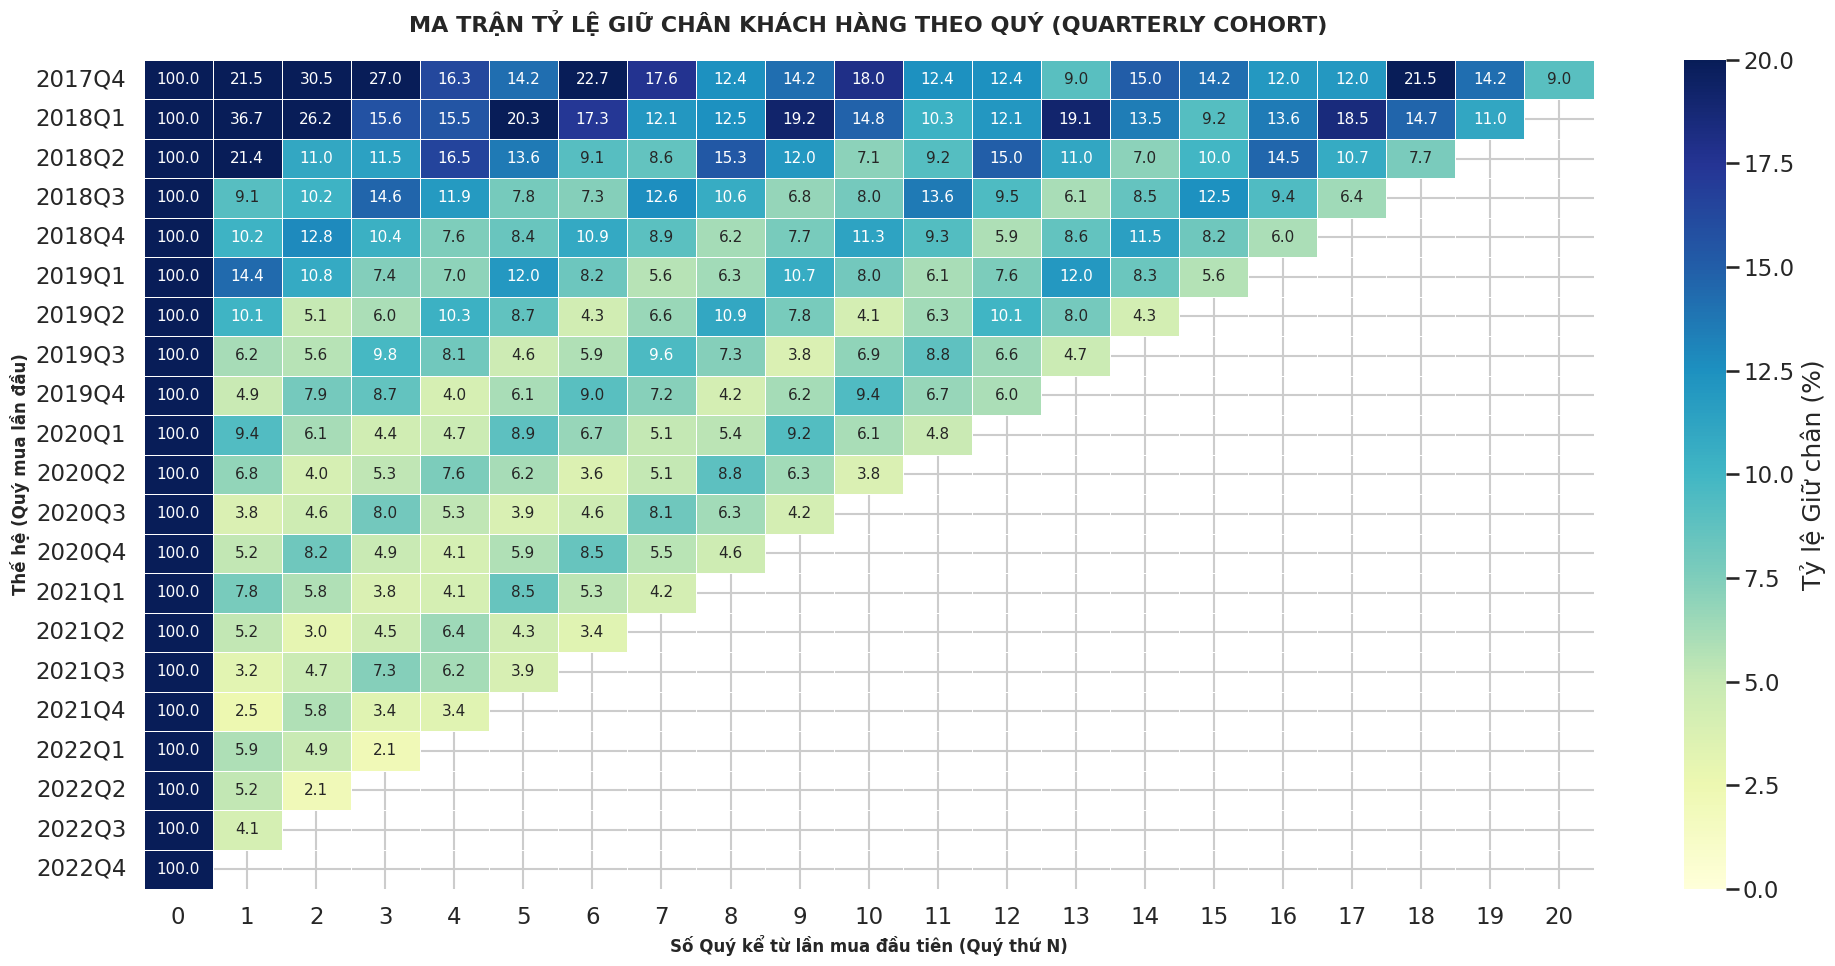

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 ĐANG XÂY DỰNG MA TRẬN COHORT RETENTION (THEO QUÝ)...")

# ==============================================================================
# BƯỚC 1: XÁC ĐỊNH THẾ HỆ VÀ KHOẢNG CÁCH (THEO QUÝ)
# ==============================================================================
# Lấy bảng hóa đơn thành công
df_cohort_q = df_success[['customer_id', 'order_date']].copy()
df_cohort_q['order_date'] = pd.to_datetime(df_cohort_q['order_date'])

# Chuyển đổi sang định dạng Quý (VD: 2021Q1, 2021Q2)
df_cohort_q['order_quarter'] = df_cohort_q['order_date'].dt.to_period('Q')

# Tìm Quý mua hàng ĐẦU TIÊN của khách (Cohort Quarter)
df_cohort_q['cohort_quarter'] = df_cohort_q.groupby('customer_id')['order_date'].transform('min').dt.to_period('Q')

# Tính khoảng cách (Số Quý chênh lệch)
df_cohort_q['quarter_index'] = (df_cohort_q['order_quarter'] - df_cohort_q['cohort_quarter']).apply(lambda x: x.n)

# ==============================================================================
# BƯỚC 2: TẠO MA TRẬN TỶ LỆ (%)
# ==============================================================================
# Đếm số khách hàng Active
cohort_data_q = df_cohort_q.groupby(['cohort_quarter', 'quarter_index'])['customer_id'].nunique().reset_index()

# Pivot xoay bảng
cohort_pivot_q = cohort_data_q.pivot(index='cohort_quarter', columns='quarter_index', values='customer_id')

# Lấy cột Index 0 (Lượng khách Quý đầu) làm mẫu số
cohort_sizes_q = cohort_pivot_q.iloc[:, 0]

# Tính tỷ lệ %
retention_matrix_q = cohort_pivot_q.divide(cohort_sizes_q, axis=0) * 100

# ==============================================================================
# BƯỚC 3: VẼ BẢN ĐỒ NHIỆT (HEATMAP)
# ==============================================================================
plt.figure(figsize=(20, 10))
plt.title('MA TRẬN TỶ LỆ GIỮ CHÂN KHÁCH HÀNG THEO QUÝ (QUARTERLY COHORT)',
          fontsize=16, fontweight='bold', pad=20)

# Cấu hình dữ liệu để vẽ
matrix_to_plot_q = retention_matrix_q.copy()
matrix_to_plot_q.index = matrix_to_plot_q.index.astype(str)

# Vẽ Heatmap
sns.heatmap(matrix_to_plot_q,
            annot=True,
            fmt='.1f',
            cmap='YlGnBu',
            vmin=0.0, vmax=20.0, # Nâng giới hạn màu lên 20% do gộp quý tỷ lệ sẽ cao hơn
            linewidths=.5,
            annot_kws={"size": 11},
            cbar_kws={'label': 'Tỷ lệ Giữ chân (%)'})

plt.ylabel('Thế hệ (Quý mua lần đầu)', fontsize=12, fontweight='bold')
plt.xlabel('Số Quý kể từ lần mua đầu tiên (Quý thứ N)', fontsize=12, fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

🩺 ĐANG TIẾN HÀNH KIỂM ĐỊNH TÍNH ỔN ĐỊNH CỦA CHUỖI THỜI GIAN...
--------------------------------------------------
Chỉ số p-value từ Kiểm định ADF: 0.0063
✅ KẾT LUẬN: p-value < 0.05. Dữ liệu có Tính dừng (Stationary). ĐỦ ỔN ĐỊNH để áp dụng các mô hình ARIMA/Prophet.
--------------------------------------------------


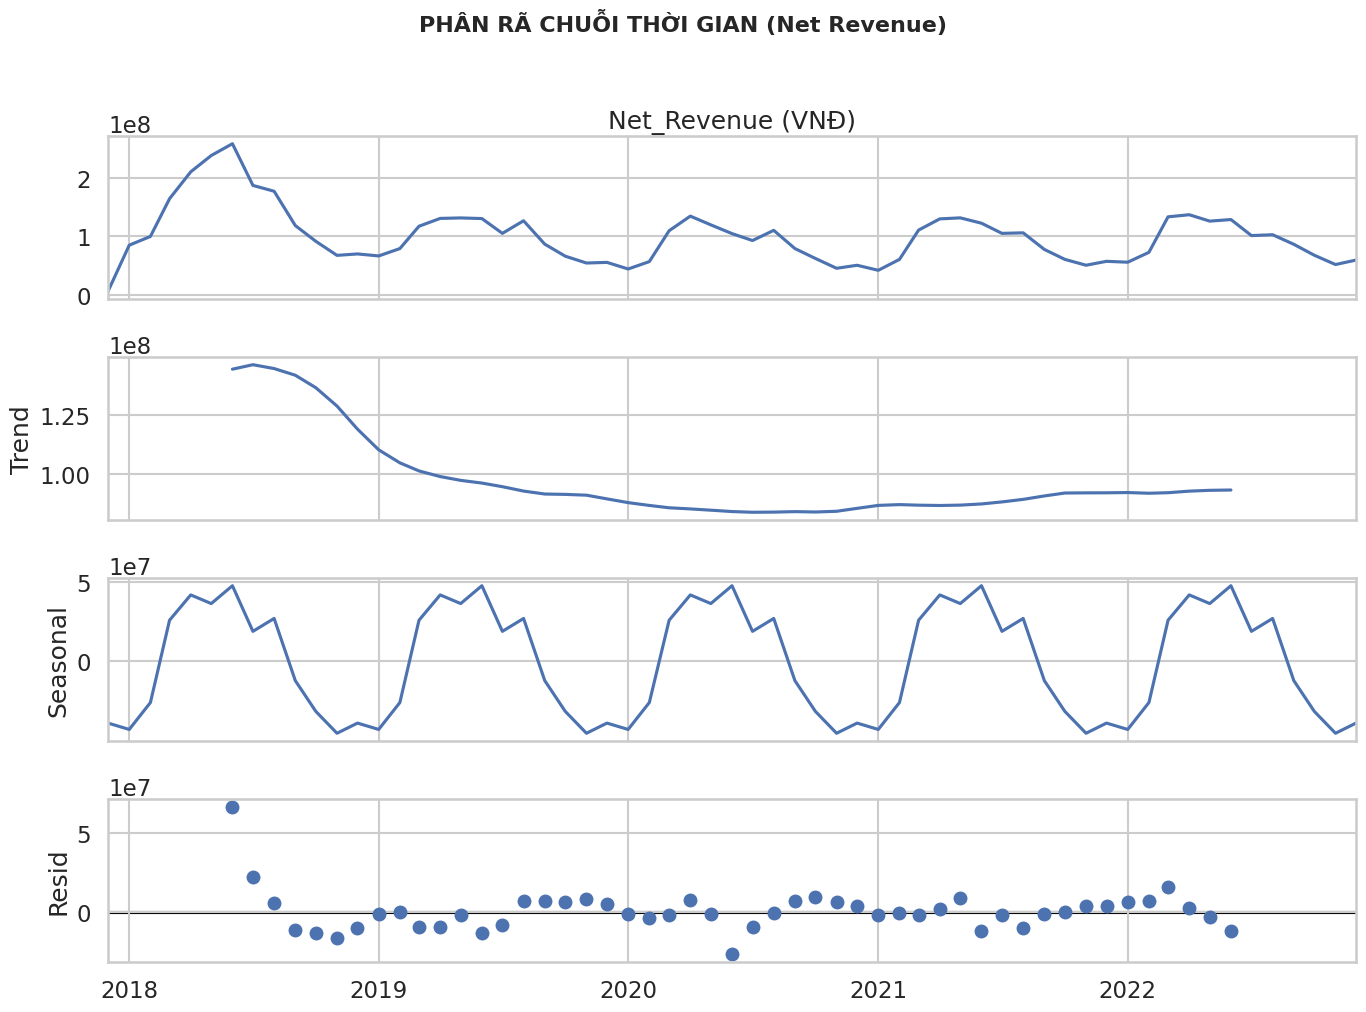

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

print("🩺 ĐANG TIẾN HÀNH KIỂM ĐỊNH TÍNH ỔN ĐỊNH CỦA CHUỖI THỜI GIAN...")

# Giả sử bạn có bảng monthly_data với cột 'Month' và 'Net_Revenue'
# Chuẩn bị dữ liệu: Đặt cột thời gian làm Index
df_test = df_metrics[['Tháng', 'Net_Revenue (VNĐ)']].copy()
df_test['Tháng'] = pd.to_datetime(df_test['Tháng'])
df_test.set_index('Tháng', inplace=True)

# 1. KIỂM ĐỊNH ADF (Augmented Dickey-Fuller Test)
result = adfuller(df_test['Net_Revenue (VNĐ)'].dropna())
p_value = result[1]

print("-" * 50)
print(f"Chỉ số p-value từ Kiểm định ADF: {p_value:.4f}")

if p_value < 0.05:
    print("✅ KẾT LUẬN: p-value < 0.05. Dữ liệu có Tính dừng (Stationary). ĐỦ ỔN ĐỊNH để áp dụng các mô hình ARIMA/Prophet.")
else:
    print("❌ KẾT LUẬN: p-value >= 0.05. Dữ liệu KHÔNG có Tính dừng (Non-Stationary). RẤT BẤT ỔN định.")
    print("➡️ Giải pháp: Phải lấy sai phân (Differencing), hoặc dùng phương pháp dự báo Bottom-up (Cohort-based).")
print("-" * 50)

# 2. TRỰC QUAN HÓA BẰNG DECOMPOSITION (Bóc tách Mùa vụ & Xu hướng)
# Đặt period=12 vì chu kỳ thường là 12 tháng
decompose_result = seasonal_decompose(df_test['Net_Revenue (VNĐ)'].dropna(), model='additive', period=12)

plt.rc('figure', figsize=(14, 10))
decompose_result.plot()
plt.suptitle('PHÂN RÃ CHUỖI THỜI GIAN (Net Revenue)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()